In [251]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Go up one level from doomsday/ to habitability/
sys.path.insert(0, str(Path.cwd().parent))
from calculator import SeaIceCalc, Habitability, SST, SRD, Tempdiff, Tempdiffall

Open the file

In [252]:
file = "../../solarflux/stability/run_1.25_5yr/output_daily.nc"
ds = xr.open_dataset(file)
# ds_crop = ds.sel(time=slice("2002-01-01", "2002-12-31"))

Extract habitability for each month

In [253]:
results_hab = []
yearly_data = ds.groupby("time.year")

In [254]:
for year, year_ds in yearly_data:

    hab = {
        "month": None,
        "sm_tot": [],  "sm_nhem": [],  "sm_shem": [],
        "st_tot": [],  "st_nhem": [],  "st_shem": [],
        "tsurf_tot": [], "tsurf_nhem": [], "tsurf_shem": [],
    }

    monthly_data = year_ds.groupby("time.month")
    months = np.array(sorted(monthly_data.groups.keys()), dtype=int)
    hab["month"] = months

    for month, month_ds in monthly_data:

        # Whole globe
        fraction_sm = Habitability.fraction(month_ds, "sm")[0]
        fraction_st = Habitability.fraction(month_ds, "st")[0]
        fraction_tsurf = Habitability.fraction(month_ds, "tsurf")[0]

        hab["sm_tot"].append(fraction_sm)
        hab["st_tot"].append(fraction_st)
        hab["tsurf_tot"].append(fraction_tsurf)
    
        # Northern hemisphere
        sm_n = Habitability.fraction(month_ds, "sm", lat=slice(0,24))[0]
        st_n = Habitability.fraction(month_ds, "st", lat=slice(0,24))[0]
        tsurf_n = Habitability.fraction(month_ds, "tsurf", lat=slice(0,24))[0]

        hab["sm_nhem"].append(sm_n)
        hab["st_nhem"].append(st_n)
        hab["tsurf_nhem"].append(tsurf_n)

        # Southern hemisphere
        sm_s = Habitability.fraction(month_ds, "sm", lat=slice(24,48))[0]
        st_s = Habitability.fraction(month_ds, "st", lat=slice(24,48))[0]
        tsurf_s = Habitability.fraction(month_ds, "tsurf", lat=slice(24,48))[0]

        hab["sm_shem"].append(sm_s)
        hab["st_shem"].append(st_s)
        hab["tsurf_shem"].append(tsurf_s)
    
    # convert lists of scalars to numpy arrays for math/plotting later
    for k, v in list(hab.items()):
        # keep 'month' as-is (already an array)
        if k == "month":
            continue
        # convert lists to numpy arrays
        if isinstance(v, list):
            hab[k] = np.array(v) 
    
    # Store results
    results_hab.append({"year": year, "data": hab})

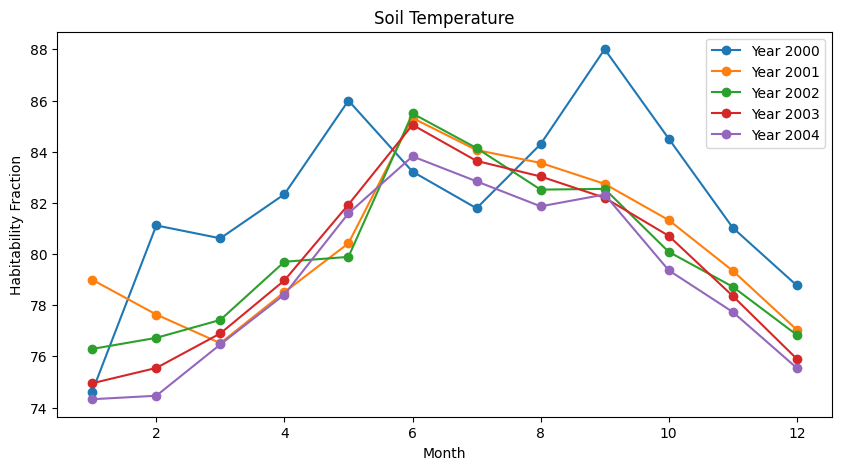

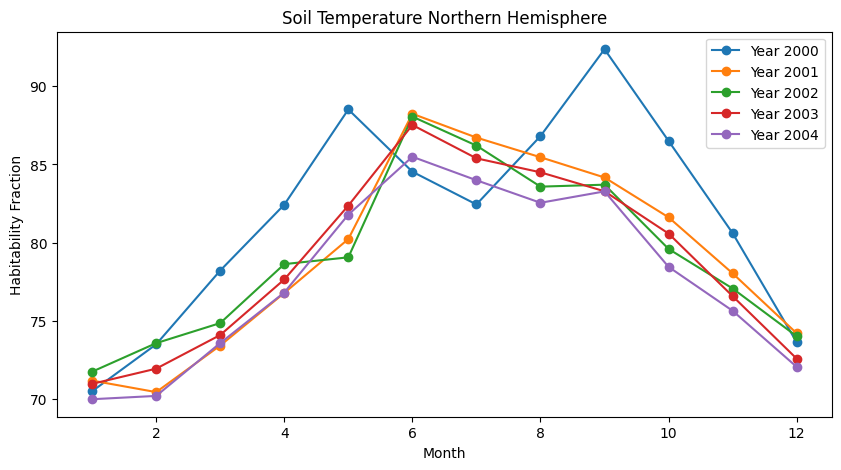

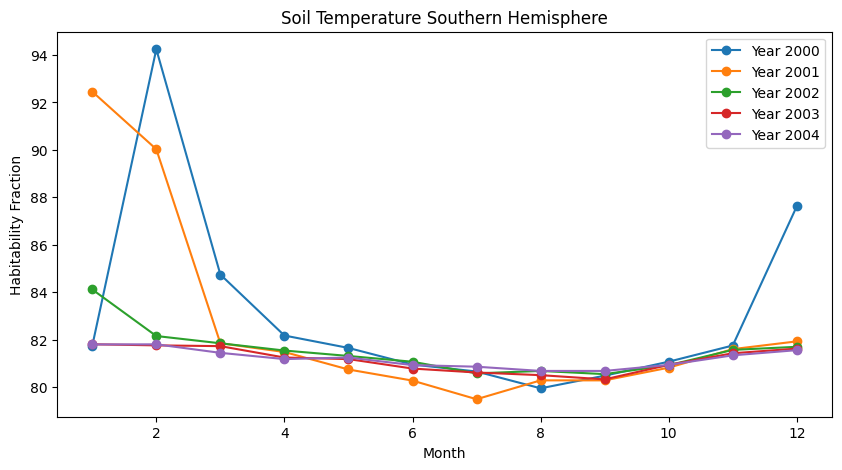

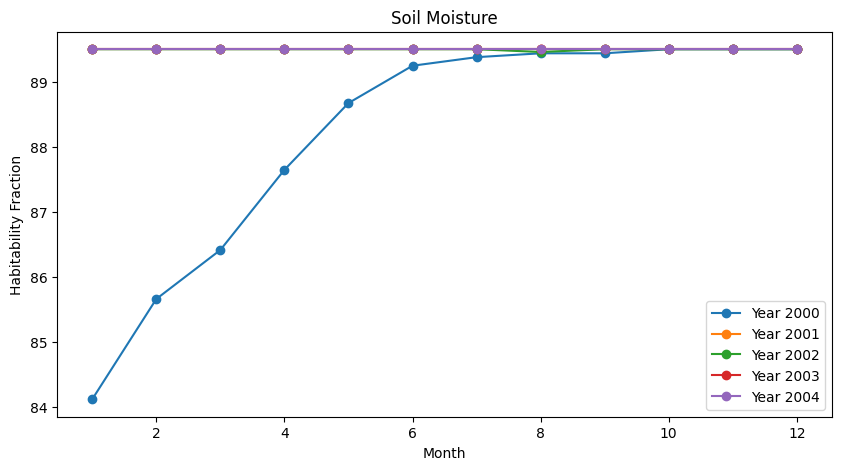

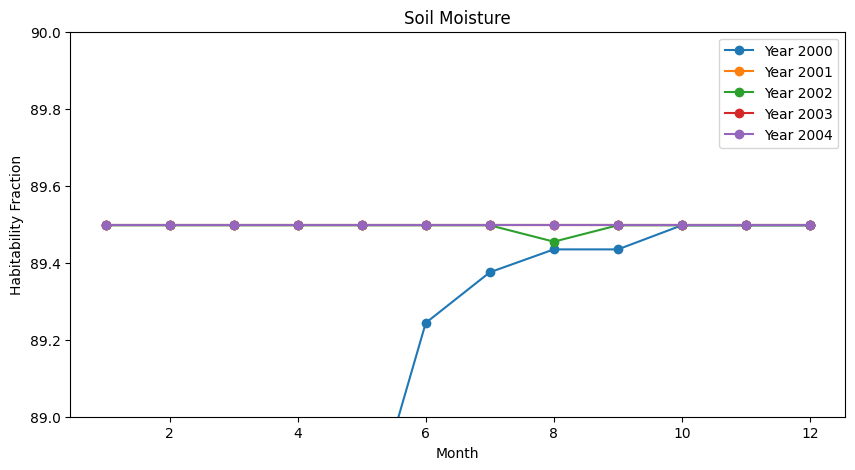

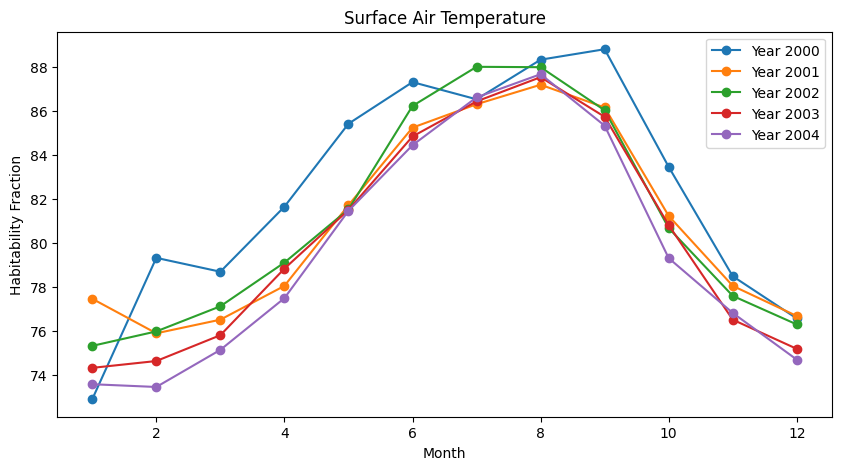

In [255]:
fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    st = yr_dict["data"]["st_tot"]
    plt.plot(month, st, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Soil Temperature")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    st = yr_dict["data"]["st_nhem"]
    plt.plot(month, st, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Soil Temperature Northern Hemisphere")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    st = yr_dict["data"]["st_shem"]
    plt.plot(month, st, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Soil Temperature Southern Hemisphere")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    sm = yr_dict["data"]["sm_tot"]
    plt.plot(month, sm, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Soil Moisture")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    sm = yr_dict["data"]["sm_tot"]
    plt.plot(month, sm, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.ylim(89,90)
plt.title("Soil Moisture")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 5))
for yr_dict in results_hab:
    year = yr_dict["year"]
    month = yr_dict["data"]["month"]
    tsurf = yr_dict["data"]["tsurf_tot"]
    plt.plot(month, tsurf, label=f"Year {year}", marker='o')

plt.xlabel("Month")
plt.title("Surface Air Temperature")
plt.ylabel("Habitability Fraction")
plt.legend()
plt.show()

In [256]:
from timeseries_calc import OceanParam, WholeGlobeParam, LandParam, SeaIce
ds_crop = ds.sel(time=slice("2003-01-01", "2003-12-31"))
times = ds_crop.time.dt.dayofyear.values

## Look at the data over the course of the 3rd year

## Start with temperature

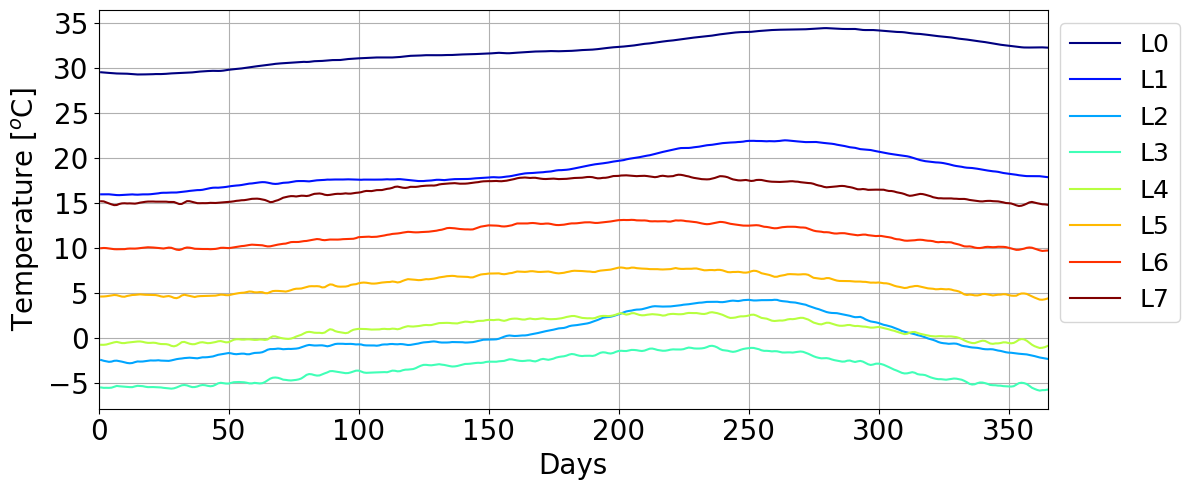

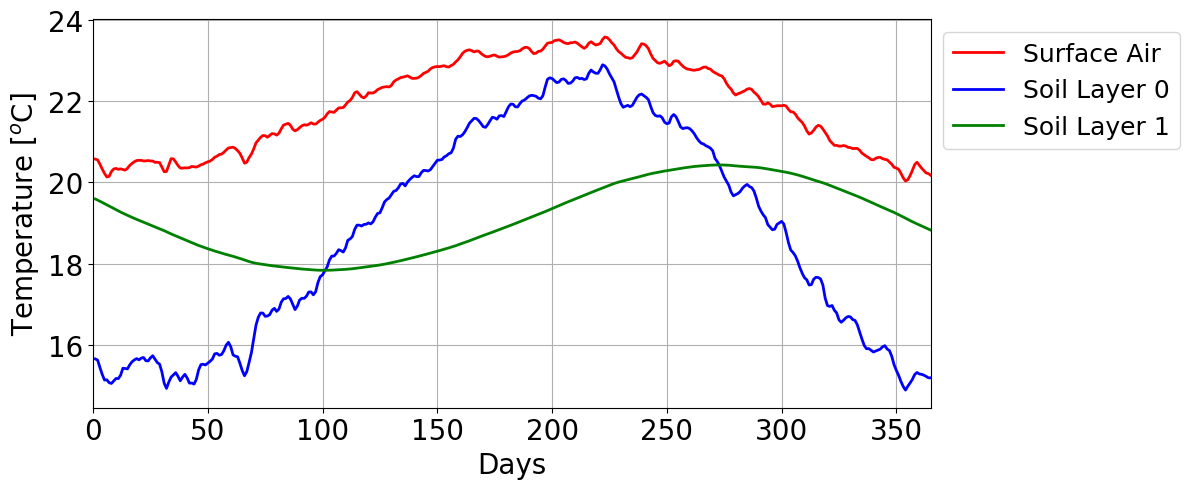

In [257]:
# Temperature

# Air temperature
n_layers = 8
cmap = plt.get_cmap("jet")

fig = plt.figure(figsize=(12, 5))
for i in range(n_layers):
    li = WholeGlobeParam.globalparam_timeseries(
        ds_crop["temp"].isel(layer=i)
    )

    # evenly spaced colour from colormap
    color = cmap(i / (n_layers - 1))

    plt.plot(times, li, color=color, label=f"L{i}")

plt.ylabel("Temperature [$^o$C]", size=20)
plt.xlabel("Days", size=20)
plt.xlim(0, 365)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

# Soil and surface air temperature
tsurf = WholeGlobeParam.globalparam_timeseries(ds_crop["tsurf"])
st_l0 = LandParam.landparam_timeseries(ds_crop["st"].isel(soil_layer=0),ds_crop["lsm"])
st_l1 = LandParam.landparam_timeseries(ds_crop["st"].isel(soil_layer=1),ds_crop["lsm"])

fig = plt.figure(figsize=(12, 5))
plt.plot(times, tsurf, color='red', label="Surface Air", linewidth=2)
plt.plot(times, st_l0, color='blue', label="Soil Layer 0", linewidth=2)
plt.plot(times, st_l1, color='green', label="Soil Layer 1", linewidth=2)
plt.ylabel("Temperature [$^o$C]", size=20)
plt.xlabel('Days', size=20)
plt.xlim(0,365)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18, bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

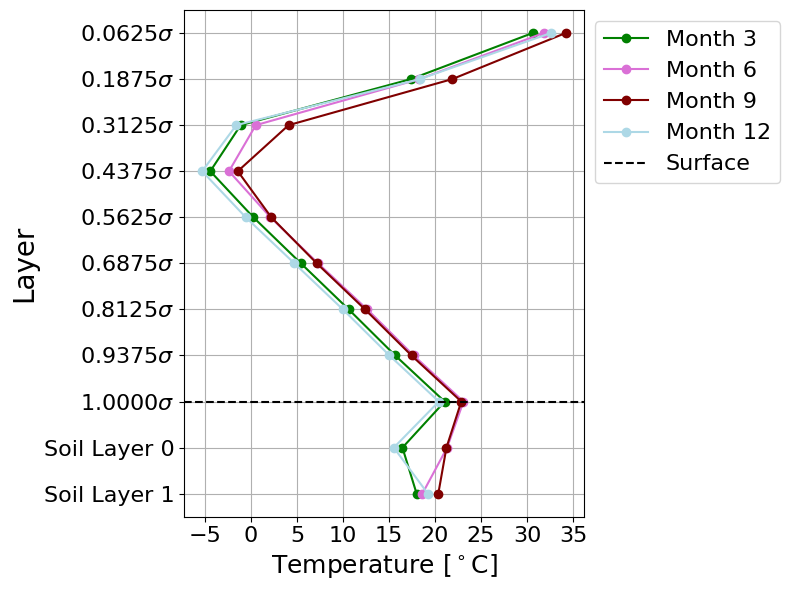

In [258]:
# Calculate temperature every 3 months in each layer
# Plot temperature vertically for each layer every 3 months

months_to_keep = [3,6,9,12]

# Functions that return a scalar for a given monthly dataset
def layer_temp_mean(month_ds, layer_idx):
    return WholeGlobeParam.globalparam_timeseries(month_ds["temp"].isel(layer=layer_idx)).mean()

def tsurf_mean(month_ds):
    return WholeGlobeParam.globalparam_timeseries(month_ds["tsurf"]).mean()

def st_mean(month_ds, soil_layer_idx):
    # keep same lsm choice you used previously
    lsm_mask = month_ds["lsm"].any("time")
    return LandParam.landparam_timeseries(month_ds["st"].isel(soil_layer=soil_layer_idx), lsm=lsm_mask).mean()

# The ordered list of "layers" we plot (0..7 temp layers, then tsurf, st0, st1)
sigma_vals = [0.0625, 0.1875, 0.3125, 0.4375, 0.5625, 0.6875, 0.8125, 0.9375, 1]
layer_labels = [f"{s:.4f}$\\sigma$" for s in sigma_vals] + ["Soil Layer 0", "Soil Layer 1"]
n_layers = len(layer_labels)

# compute a DataFrame: rows = months, columns = layers
results = pd.DataFrame(index=months_to_keep, columns=layer_labels, dtype=float)

grouped_data = ds_crop.groupby("time.month")
for month, month_ds in grouped_data:
    if month in months_to_keep:
        vals = []
        # temp layers 0..7
        for i in range(8):
            vals.append(layer_temp_mean(month_ds, i))
        # tsurf
        vals.append(tsurf_mean(month_ds))
        # st layers 0..1
        vals.append(st_mean(month_ds, 0))
        vals.append(st_mean(month_ds, 1))

        results.loc[month] = vals

import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(8, 6))

# y positions (0..n_layers-1); use labels on ticks
y_pos = list(range(n_layers))

custom_colors = ["green", "orchid", "maroon", "lightblue"] 

for idx, month in enumerate(months_to_keep):
    color = custom_colors[idx]
    ax.plot(results.loc[month].values, y_pos, marker='o', label=f"Month {int(month)}", color=color)

ax.set_xlabel("Temperature [$^\\circ$C]", size=18)
ax.set_ylabel("Layer", size=20)
ax.set_yticks(y_pos)
ax.set_yticklabels(layer_labels, size = 16)
xticks = [-5,0, 5, 10, 15, 20, 25, 30, 35]
ax.set_xticks(xticks)
ax.tick_params(axis='x', labelsize=16)
ax.invert_yaxis()   # optional: invert if you want layer0 at top
ax.grid(True)
ax.axhline(y_pos[8],linestyle="--", color="black", label="Surface")
ax.legend(fontsize=16, bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()


In [259]:
# Compare with Earth

file_earth = "../../earth/output.nc"
earth_data = xr.open_dataset(file_earth)
earth_crop = earth_data.sel(time=slice("2003-01-01", "2003-12-31"))

file_snow = "../../solarflux/stability/run_0.1_5yr/output.nc"
ds_snow = xr.open_dataset(file_snow)
snow_crop = ds_snow.sel(time=slice("2003-01-01", "2004-01-01"))

# Functions that return a scalar for a given monthly dataset
def layer_temp_mean(ds, layer_idx):
    return WholeGlobeParam.globalparam_timeseries(ds["temp"].isel(layer=layer_idx)).mean()

def tsurf_mean(ds):
    return WholeGlobeParam.globalparam_timeseries(ds["tsurf"]).mean()

def st_mean(ds, soil_layer_idx):
    # keep same lsm choice you used previously
    lsm_mask = ds["lsm"]
    return LandParam.landparam_timeseries(ds["st"].isel(soil_layer=soil_layer_idx), lsm=lsm_mask).mean()

# The ordered list of "layers" we plot (0..7 temp layers, then tsurf, st0, st1)
sigma_vals = [0.0625, 0.1875, 0.3125, 0.4375, 0.5625, 0.6875, 0.8125, 0.9375, 1]
layer_labels = [f"{s:.4f}$\\sigma$" for s in sigma_vals] + ["Soil Layer 0", "Soil Layer 1"]
n_layers = len(layer_labels)

# compute a DataFrame: rows = months, columns = layers
results = pd.DataFrame(index=months_to_keep, columns=layer_labels, dtype=float)

# Earth vals
vals_earth = []
for i in range(8):
        vals_earth.append(layer_temp_mean(earth_crop, i))
vals_earth.append(tsurf_mean(earth_crop))
vals_earth.append(st_mean(earth_crop, 0))
vals_earth.append(st_mean(earth_crop, 1))

# New planet vals
vals_hot = []
for i in range(8):
        vals_hot.append(layer_temp_mean(ds_crop, i))
vals_hot.append(tsurf_mean(ds_crop))
vals_hot.append(st_mean(ds_crop, 0))
vals_hot.append(st_mean(ds_crop, 1))

# Snowball vals
vals_snow = []
for i in range(8):
        vals_snow.append(layer_temp_mean(snow_crop, i))
vals_snow.append(tsurf_mean(snow_crop))
vals_snow.append(st_mean(snow_crop, 0))
vals_snow.append(st_mean(snow_crop, 1))

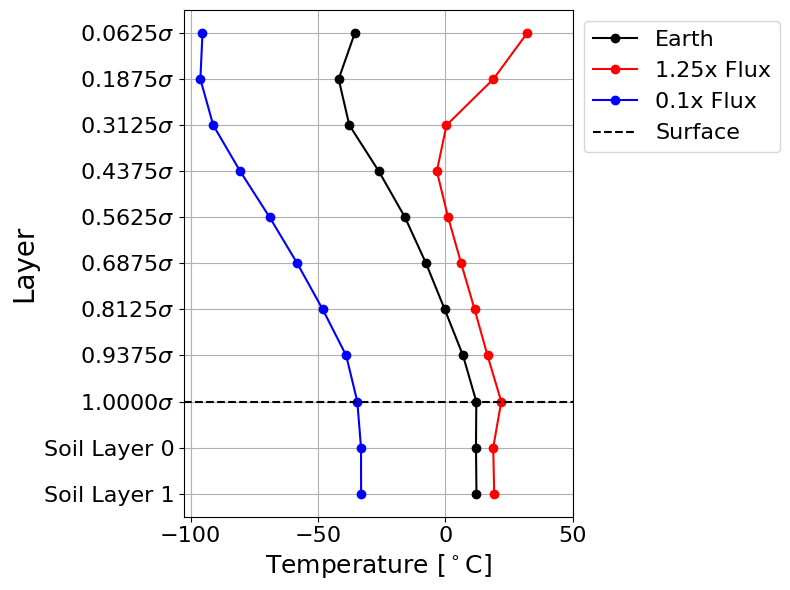

In [260]:

import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = list(range(n_layers))
ax.plot(vals_earth, y_pos, marker='o', label="Earth", color="black")
ax.plot(vals_hot, y_pos, marker='o', label="1.25x Flux", color="red")
ax.plot(vals_snow, y_pos, marker='o', label="0.1x Flux", color="blue")
ax.set_xlabel("Temperature [$^\\circ$C]", size=18)
ax.set_ylabel("Layer", size=20)
ax.set_yticks(y_pos)
ax.set_yticklabels(layer_labels, size = 16)
xticks = [-100,-50,0,50]
ax.set_xticks(xticks)
ax.tick_params(axis='x', labelsize=16)
ax.invert_yaxis()   # optional: invert if you want layer0 at top
ax.grid(True)
ax.axhline(y_pos[8],linestyle="--", color="black", label="Surface")
ax.legend(fontsize=16, bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

In [329]:
# Compare humidity with Earth
def layer_humid_mean(ds, layer_idx):
    return WholeGlobeParam.globalparam_timeseries(ds["humid"].isel(layer=layer_idx)).mean()

# The ordered list of "layers" we plot (0..7 temp layers, then tsurf, st0, st1)
sigma_vals_humid = [0.0625, 0.1875, 0.3125, 0.4375, 0.5625, 0.6875, 0.8125, 0.9375]
layer_labels_humid = [f"{s:.4f}$\\sigma$" for s in sigma_vals_humid]
n_layers_humid = len(layer_labels_humid)

# compute a DataFrame: rows = months, columns = layers
results_humid = pd.DataFrame(index=months_to_keep, columns=layer_labels_humid, dtype=float)

# Earth vals
vals_earth_humid = []
vals_hot_humid = []
vals_snow_humid = []
for i in range(8):
        vals_earth_humid.append(layer_humid_mean(earth_crop, i))
        vals_hot_humid.append(layer_humid_mean(ds_crop, i))
        vals_snow_humid.append(layer_humid_mean(snow_crop, i))


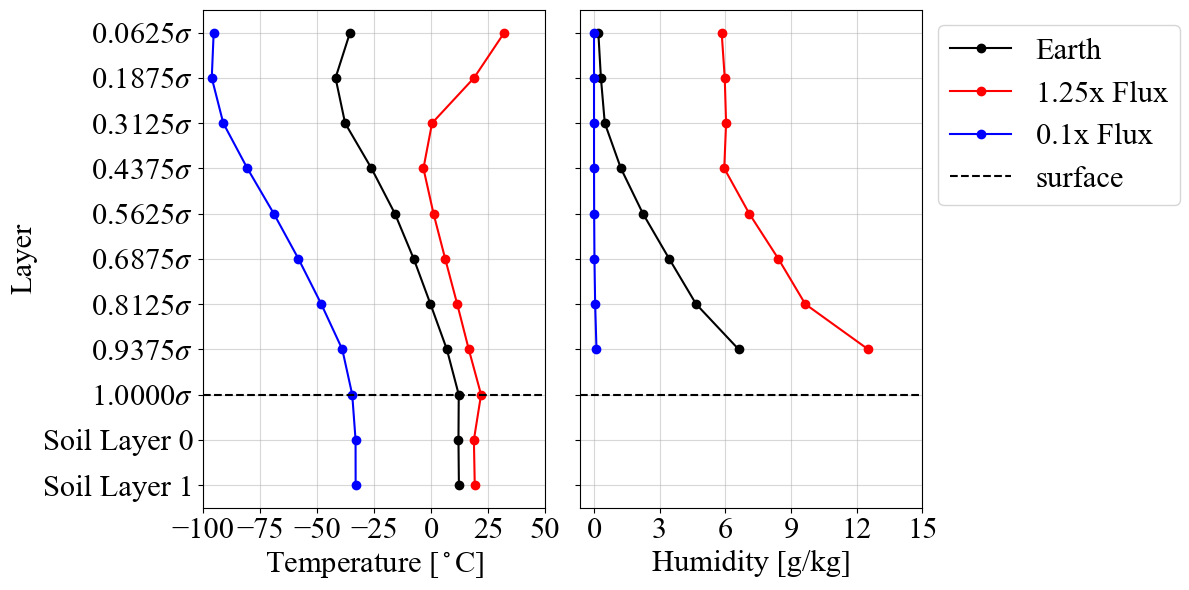

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Global Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'

fig, (ax1, ax2) = plt.subplots(
    ncols=2, 
    figsize=(12, 6), 
    sharey=True
)

y_pos = list(range(n_layers))

ax1.plot(vals_earth, y_pos, marker='o', label="Earth", color="black")
ax1.plot(vals_hot, y_pos, marker='o', label="1.25x Flux", color="red")
ax1.plot(vals_snow, y_pos, marker='o', label="0.1x Flux", color="blue")

ax1.set_xlabel("Temperature [$^\\circ$C]", size=22)
ax1.set_ylabel("Layer", size=22)
ax1.set_yticks(y_pos)
ax1.set_xlim(-100,50)
ax1.set_yticklabels(layer_labels, size=22)
ax1.set_xticks([-100,-75, -50, -25, 0, 25,50])
ax1.tick_params(axis='x', labelsize=22)
ax1.invert_yaxis()
ax1.grid(True, alpha=0.5)
ax1.axhline(y_pos[8], linestyle="--", color="black", label="surface")

y_pos_h = list(range(n_layers_humid))
vals_earth_humid2 = np.array(vals_earth_humid) * 1000
vals_hot_humid2 = np.array(vals_hot_humid) * 1000
vals_snow_humid2 = np.array(vals_snow_humid) * 1000
ax2.plot(vals_earth_humid2, y_pos_h, marker='o', label="Earth", color="black")
ax2.plot(vals_hot_humid2, y_pos_h, marker='o', label="1.25x Flux", color="red")
ax2.plot(vals_snow_humid2, y_pos_h, marker='o', label="0.1x Flux", color="blue")

ax2.set_xlabel("Humidity [g/kg]", size=22)
# ax2.set_xticks([0, 0.01])
ax2.tick_params(axis='x', labelsize=22)
ax2.set_xticks([0,3,6,9,12,15])
ax2.grid(True, alpha=0.5)
ax2.axhline(8, linestyle="--", color="black", label="surface")

ax2.legend(fontsize=22, bbox_to_anchor=(1, 1))
plt.tight_layout()
# plt.savefig("1.25flux_temphumid.png", dpi=300, bbox_inches='tight')
plt.show()

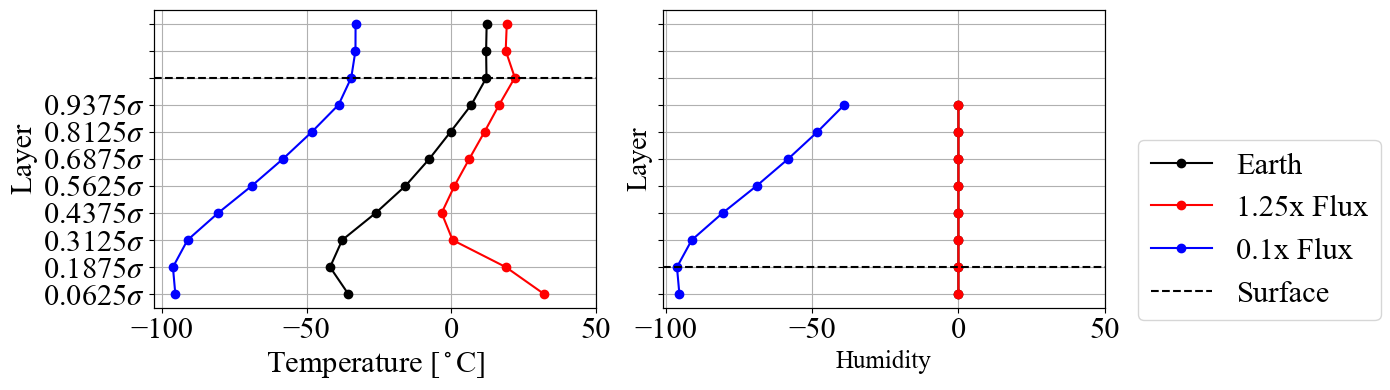

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Global Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax2_0 = ax[0].twinx()
ax2_1 = ax[1].twinx()

xticks = [-100,-50,0,50]

# -------- First plot --------
y_pos = list(range(n_layers))
ax[0].plot(vals_earth, y_pos, marker='o', label="Earth", color="black")
ax[0].plot(vals_hot, y_pos, marker='o', label="1.25x Flux", color="red")
ax[0].plot(vals_snow, y_pos, marker='o', label="0.1x Flux", color="blue")
ax[0].set_xlabel("Temperature [$^\\circ$C]", size=22)
ax[0].set_ylabel("Layer", fontsize=22)
ax[0].set_yticks(y_pos)
ax[0].set_yticklabels(layer_labels, size = 22)
ax[0].set_xticks(xticks)
ax[0].tick_params(axis='x', labelsize=16)
ax[0].invert_yaxis()   # optional: invert if you want layer0 at top
ax[0].grid(True)
ax[0].axhline(y_pos[8],linestyle="--", color="black", label="Surface")

# -------- Second plot --------
y_pos_h = list(range(n_layers_humid))
ax[1].plot(vals_earth_humid, y_pos_h, marker='o', label="Earth", color="black")
ax[1].plot(vals_hot_humid, y_pos_h, marker='o', label="1.25x Flux", color="red")
ax[1].plot(vals_snow_humid, y_pos_h, marker='o', label="0.1x Flux", color="blue")
ax[1].set_xlabel("Humidity", size=18)
ax[1].set_ylabel("Layer", size=20)
ax[1].set_yticks(y_pos_h)
ax[1].set_yticklabels(layer_labels_humid, size = 16)
ax[1].set_xticks(xticks)
ax[1].tick_params(axis='x', labelsize=16)
ax[1].invert_yaxis()
ax[1].grid(True)
ax[1].axhline(1,linestyle="--", color="black", label="Surface")

# -------- Force Y limits AFTER plotting --------
ax[0].set_yticks(y_pos)

# Remove right-axis ticks (optional clean look)
ax2_0.set_yticks([])
ax2_1.set_yticks([])

ax[0].tick_params(axis='both', labelsize=22)
ax[1].tick_params(axis='both', labelsize=22)

# -------- Legend closer --------
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc="lower left",
    bbox_to_anchor=(0.94, 0.15),
    fontsize=22
)

plt.tight_layout(rect=[0, 0, 0.95, 1])
# plt.savefig("rot_season_hab.png", dpi=300, bbox_inches='tight')
plt.show()

## Now Look at habitability

Surface temperature is what's important for habitability so start with these

In [261]:
# Get the habitability for Earth
results_hab_earth = []
yearly_data_earth = earth_data.groupby("time.year")

for year, year_ds in yearly_data_earth:

    hab = {
        "month": None,
        "sm_tot": [],  "sm_nhem": [],  "sm_shem": [],
        "st_tot": [],  "st_nhem": [],  "st_shem": [],
        "tsurf_tot": [], "tsurf_nhem": [], "tsurf_shem": [],
    }

    monthly_data = year_ds.groupby("time.month")
    months = np.array(sorted(monthly_data.groups.keys()), dtype=int)
    hab["month"] = months

    for month, month_ds in monthly_data:

        # Whole globe
        fraction_sm = Habitability.fraction(month_ds, "sm")[0]
        fraction_st = Habitability.fraction(month_ds, "st")[0]
        fraction_tsurf = Habitability.fraction(month_ds, "tsurf")[0]

        hab["sm_tot"].append(fraction_sm)
        hab["st_tot"].append(fraction_st)
        hab["tsurf_tot"].append(fraction_tsurf)
    
        # Northern hemisphere
        sm_n = Habitability.fraction(month_ds, "sm", lat=slice(0,24))[0]
        st_n = Habitability.fraction(month_ds, "st", lat=slice(0,24))[0]
        tsurf_n = Habitability.fraction(month_ds, "tsurf", lat=slice(0,24))[0]

        hab["sm_nhem"].append(sm_n)
        hab["st_nhem"].append(st_n)
        hab["tsurf_nhem"].append(tsurf_n)

        # Southern hemisphere
        sm_s = Habitability.fraction(month_ds, "sm", lat=slice(24,48))[0]
        st_s = Habitability.fraction(month_ds, "st", lat=slice(24,48))[0]
        tsurf_s = Habitability.fraction(month_ds, "tsurf", lat=slice(24,48))[0]

        hab["sm_shem"].append(sm_s)
        hab["st_shem"].append(st_s)
        hab["tsurf_shem"].append(tsurf_s)
    
    # convert lists of scalars to numpy arrays for math/plotting later
    for k, v in list(hab.items()):
        # keep 'month' as-is (already an array)
        if k == "month":
            continue
        # convert lists to numpy arrays
        if isinstance(v, list):
            hab[k] = np.array(v) 
    
    # Store results
    results_hab_earth.append({"year": year, "data": hab})

# Get data for snowball Earth
results_hab_snow = []
yearly_data_snow = ds_snow.groupby("time.year")

for year, year_ds in yearly_data_snow:

    hab = {
        "month": None,
        "sm_tot": [],  "sm_nhem": [],  "sm_shem": [],
        "st_tot": [],  "st_nhem": [],  "st_shem": [],
        "tsurf_tot": [], "tsurf_nhem": [], "tsurf_shem": [],
    }

    monthly_data = year_ds.groupby("time.month")
    months = np.array(sorted(monthly_data.groups.keys()), dtype=int)
    hab["month"] = months

    for month, month_ds in monthly_data:

        # Whole globe
        fraction_sm = Habitability.fraction(month_ds, "sm")[0]
        fraction_st = Habitability.fraction(month_ds, "st")[0]
        fraction_tsurf = Habitability.fraction(month_ds, "tsurf")[0]

        hab["sm_tot"].append(fraction_sm)
        hab["st_tot"].append(fraction_st)
        hab["tsurf_tot"].append(fraction_tsurf)
    
        # Northern hemisphere
        sm_n = Habitability.fraction(month_ds, "sm", lat=slice(0,24))[0]
        st_n = Habitability.fraction(month_ds, "st", lat=slice(0,24))[0]
        tsurf_n = Habitability.fraction(month_ds, "tsurf", lat=slice(0,24))[0]

        hab["sm_nhem"].append(sm_n)
        hab["st_nhem"].append(st_n)
        hab["tsurf_nhem"].append(tsurf_n)

        # Southern hemisphere
        sm_s = Habitability.fraction(month_ds, "sm", lat=slice(24,48))[0]
        st_s = Habitability.fraction(month_ds, "st", lat=slice(24,48))[0]
        tsurf_s = Habitability.fraction(month_ds, "tsurf", lat=slice(24,48))[0]

        hab["sm_shem"].append(sm_s)
        hab["st_shem"].append(st_s)
        hab["tsurf_shem"].append(tsurf_s)
    
    # convert lists of scalars to numpy arrays for math/plotting later
    for k, v in list(hab.items()):
        # keep 'month' as-is (already an array)
        if k == "month":
            continue
        # convert lists to numpy arrays
        if isinstance(v, list):
            hab[k] = np.array(v) 
    
    # Store results
    results_hab_snow.append({"year": year, "data": hab})


# Get the dictionary for year 2003
year_2003_hot = next(item for item in results_hab if item["year"] == 2003)
data_2003_hot = year_2003_hot["data"]
year_2003_earth = next(item for item in results_hab_earth if item["year"] == 2003)
data_2003_earth = year_2003_earth["data"]
year_2003_snow = next(item for item in results_hab_snow if item["year"] == 2003)
data_2003_snow = year_2003_snow["data"]


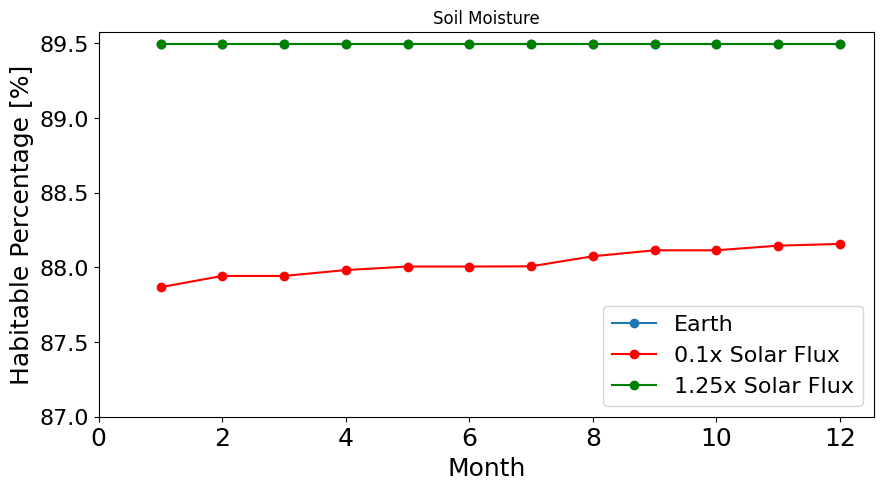

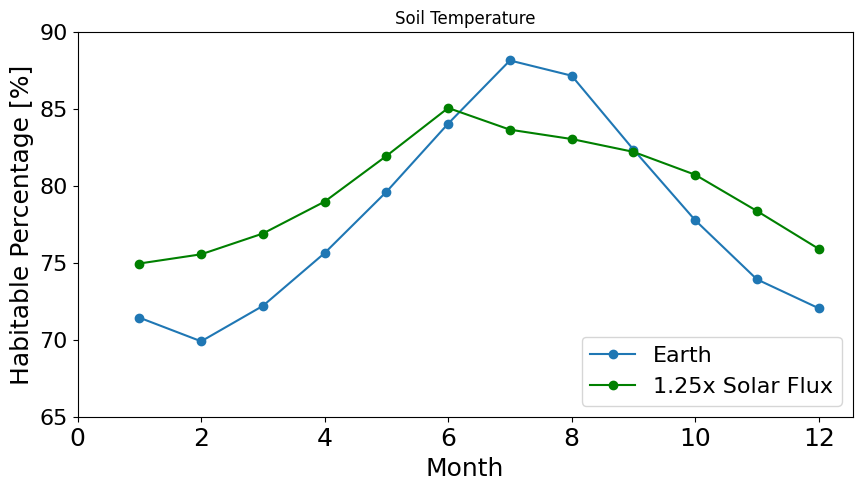

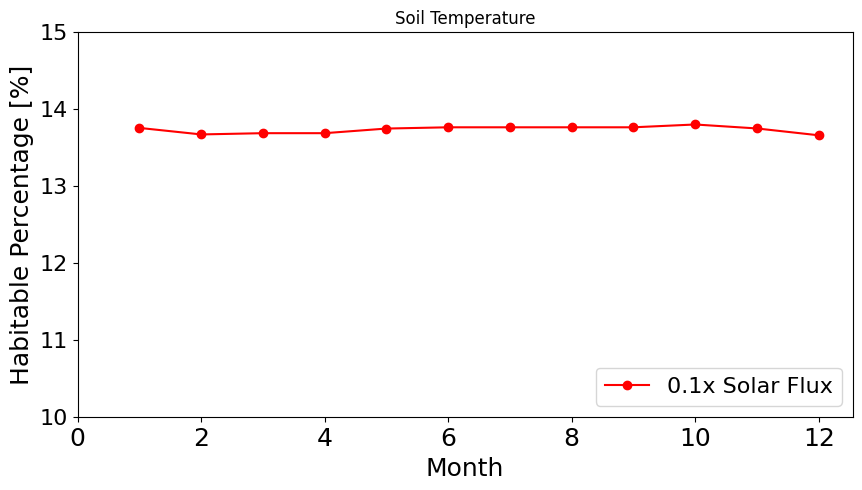

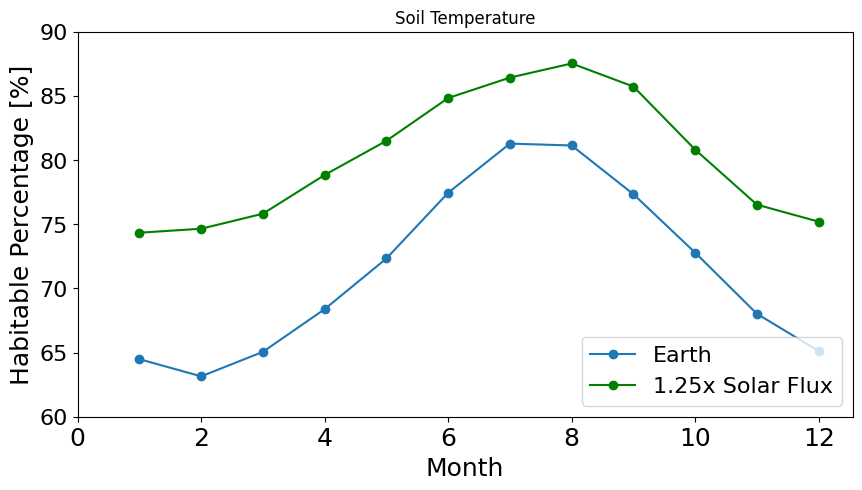

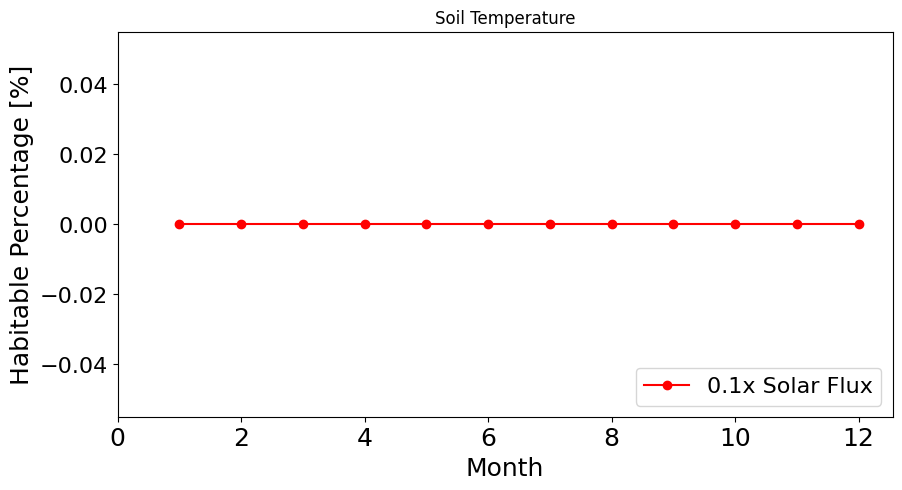

In [262]:
month = data_2003_hot["month"]
sm_hot = data_2003_hot["sm_tot"]
tsurf_hot = data_2003_hot["tsurf_tot"]
st_hot = data_2003_hot["st_tot"]
sm_earth = data_2003_earth["sm_tot"]
tsurf_earth = data_2003_earth["tsurf_tot"]
st_earth = data_2003_earth["st_tot"]
sm_snow = data_2003_snow["sm_tot"]
tsurf_snow = data_2003_snow["tsurf_tot"]
st_snow = data_2003_snow["st_tot"]

# Plot habitability for different scenarios
fig = plt.figure(figsize=(10, 5))
plt.plot(month, sm_earth, label="Earth", marker='o')
plt.plot(month, sm_snow, label="0.1x Solar Flux", marker='o', color="red")
plt.plot(month, sm_hot, label="1.25x Solar Flux", marker='o', color="green")
plt.xlabel("Month", size=18)
plt.yticks(ticks=[87,87.5,88,88.5,89,89.5],size=16)
plt.xticks([0,2,4,6,8,10,12], size=18)
plt.title("Soil Moisture")
plt.ylabel("Habitable Percentage [%]", size=18)
plt.legend(loc="lower right",fontsize=16)
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(month, st_earth, label="Earth", marker='o')
plt.plot(month, st_hot, label="1.25x Solar Flux", marker='o', color="green")
plt.xlabel("Month", size=18)
plt.yticks(ticks=[65,70,75,80,85,90],size=16)
plt.xticks([0,2,4,6,8,10,12], size=18)
plt.title("Soil Temperature")
plt.ylabel("Habitable Percentage [%]", size=18)
plt.legend(loc="lower right",fontsize=16)
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(month, st_snow, label="0.1x Solar Flux", marker='o', color="red")
plt.xlabel("Month", size=18)
plt.yticks(ticks=[10,11,12,13,14,15],size=16)
plt.xticks([0,2,4,6,8,10,12], size=18)
plt.title("Soil Temperature")
plt.ylabel("Habitable Percentage [%]", size=18)
plt.legend(loc="lower right",fontsize=16)
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(month, tsurf_earth, label="Earth", marker='o')
plt.plot(month, tsurf_hot, label="1.25x Solar Flux", marker='o', color="green")
plt.xlabel("Month", size=18)
plt.yticks(ticks=[60,65,70,75,80,85,90],size=16)
plt.xticks([0,2,4,6,8,10,12], size=18)
plt.title("Soil Temperature")
plt.ylabel("Habitable Percentage [%]", size=18)
plt.legend(loc="lower right",fontsize=16)
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(month, tsurf_snow, label="0.1x Solar Flux", marker='o', color="red")
plt.xlabel("Month", size=18)
plt.yticks(ticks=[-0.04,-0.02,0,0.02,0.04],size=16)
plt.xticks([0,2,4,6,8,10,12], size=18)
plt.title("Soil Temperature")
plt.ylabel("Habitable Percentage [%]", size=18)
plt.legend(loc="lower right",fontsize=16)
plt.show()

Look at each metric individually and assess temperature maps

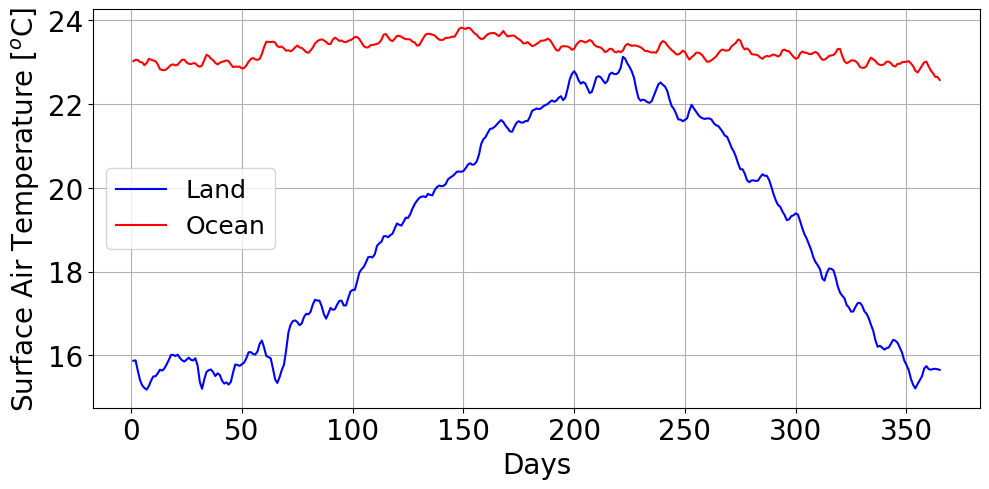

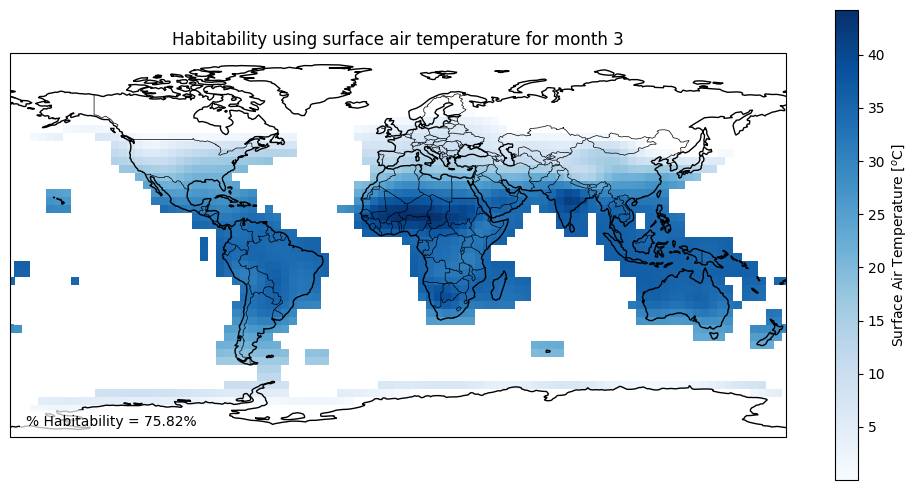

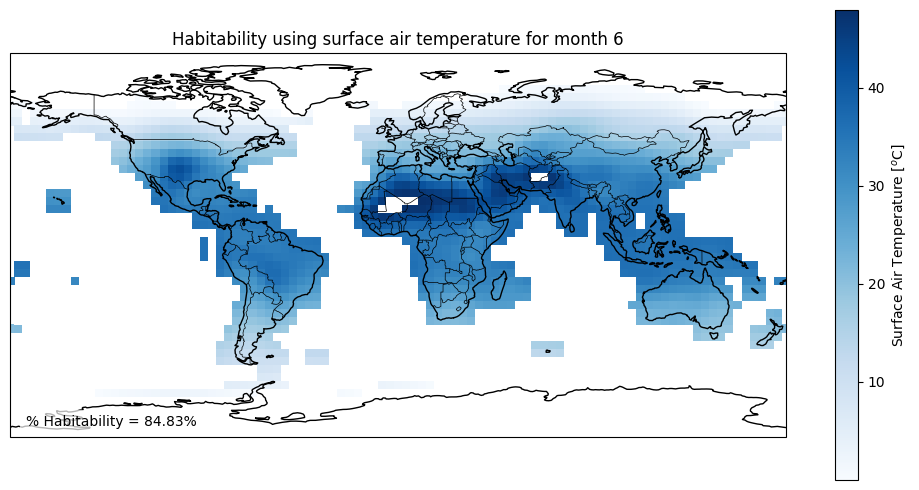

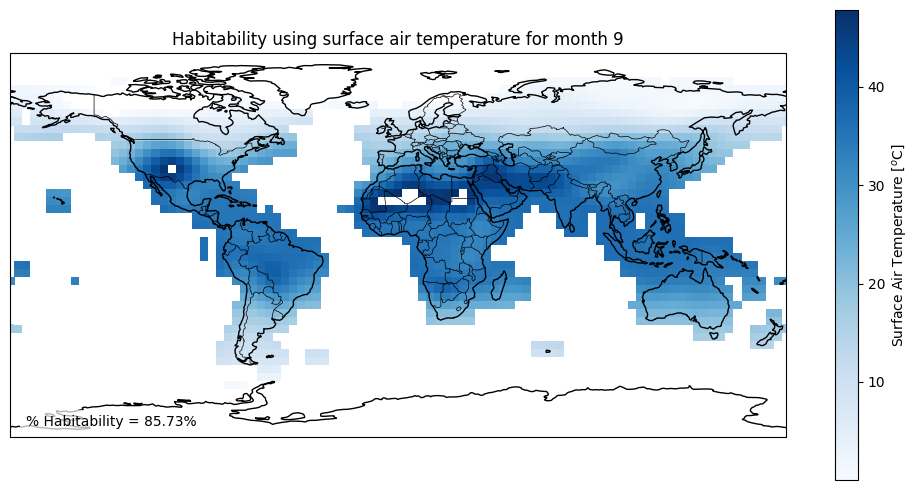

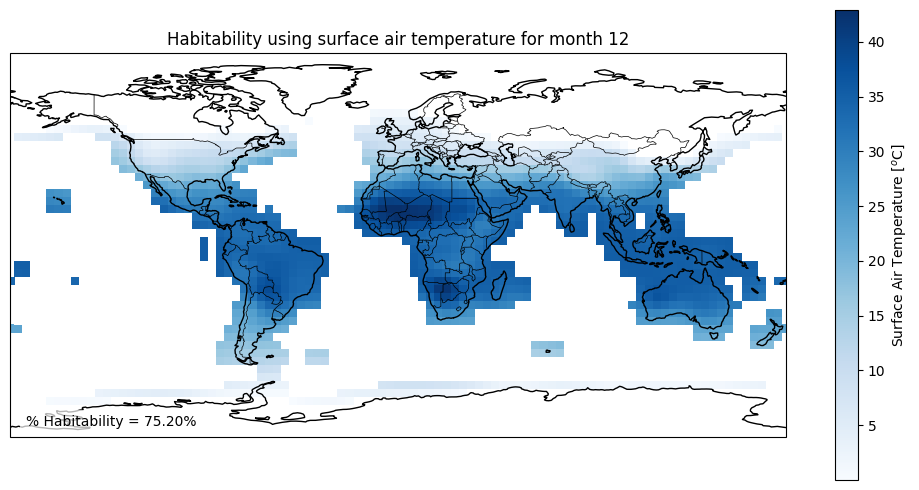

In [263]:
ts_l = LandParam.landparam_timeseries(ds_crop["tsurf"],ds_crop["lsm"])
ts_o = OceanParam.oceanparam_timeseries(ds_crop["tsurf"],ds_crop["lsm"])

fig = plt.figure(figsize=(10, 5))
plt.plot(times, ts_l, color='blue', label="Land")
plt.plot(times, ts_o, color='red', label="Ocean")
plt.ylabel("Surface Air Temperature [$^o$C]", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

months_to_keep = [3,6,9,12]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        # Soil Moisture
        fraction = Habitability.fraction(month_ds, "tsurf")[0]
        mean_plot = Habitability.fraction(month_ds, "tsurf")[1]
        habitable_plot = Habitability.fraction(month_ds, "tsurf")[2]

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        mean_plot.where(habitable_plot).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Surface Air Temperature [$^o$C]"},
            cmap="Blues"
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"% Habitability = {fraction:.2f}%",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Habitability using surface air temperature for month {month}")
    
        plt.tight_layout()

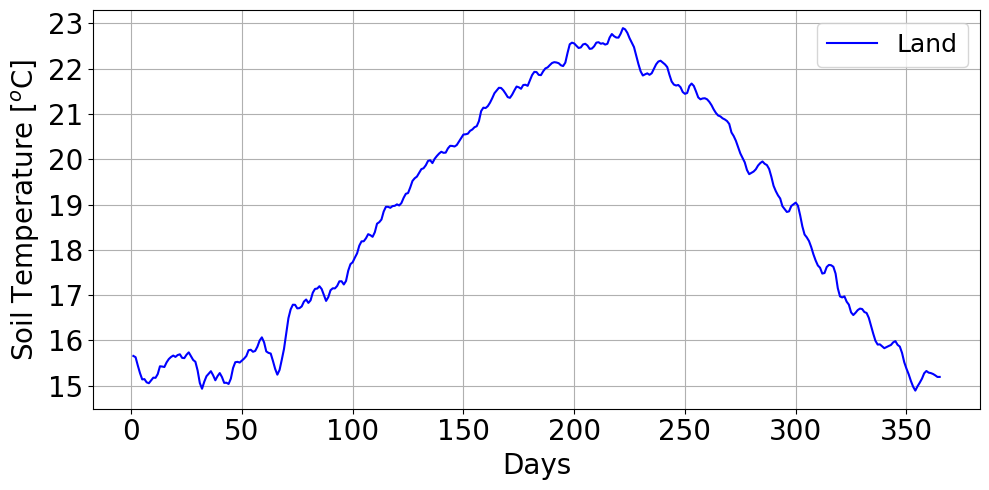

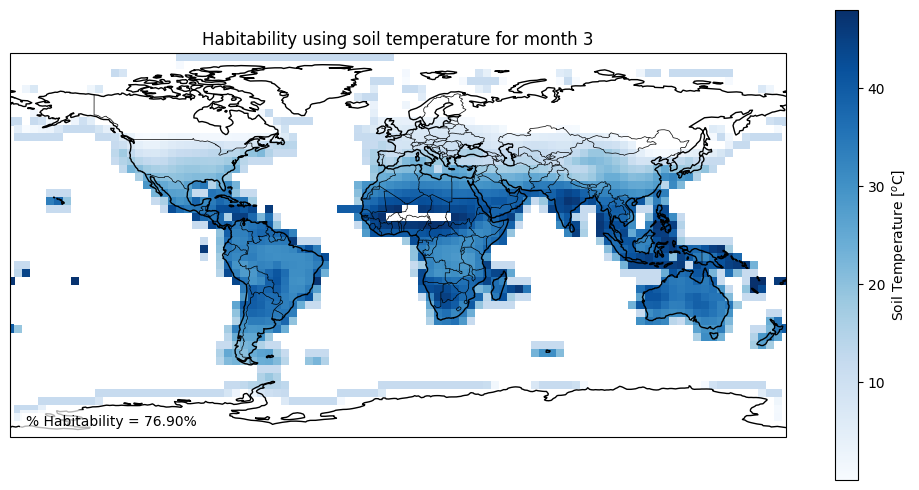

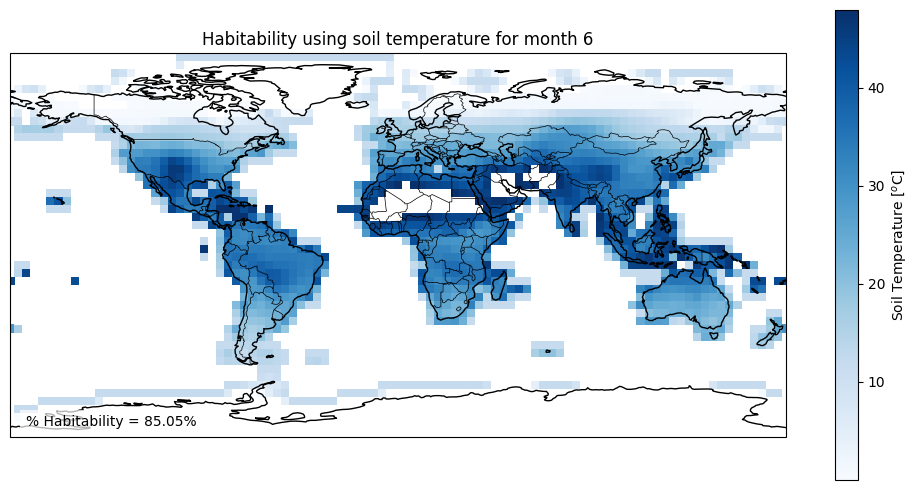

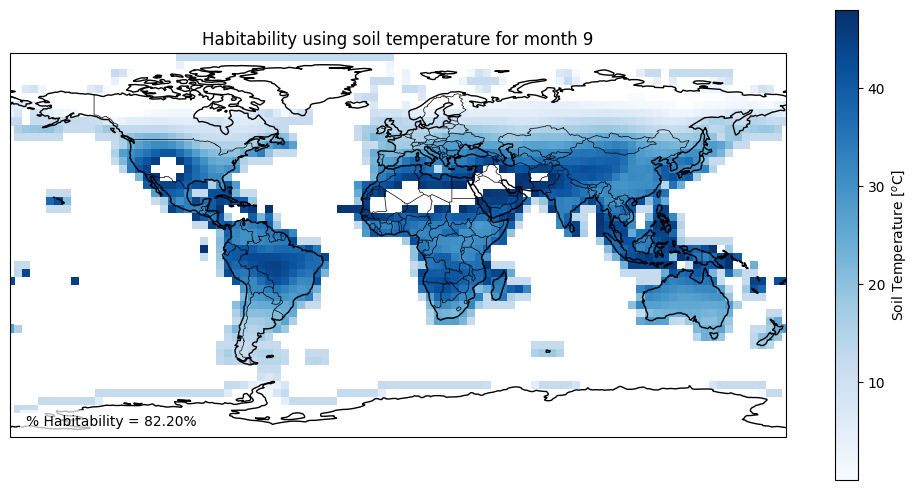

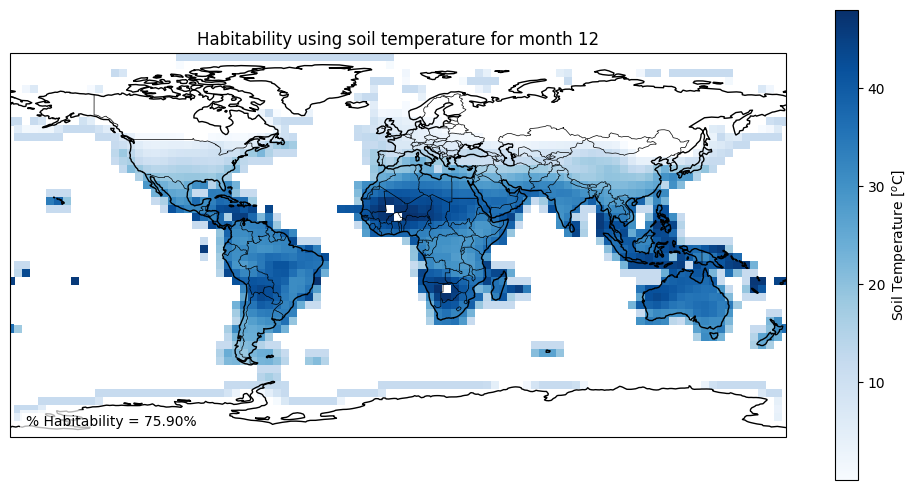

In [264]:
st_l = LandParam.landparam_timeseries(ds_crop["st"].isel(soil_layer=0),ds_crop["lsm"])

fig = plt.figure(figsize=(10, 5))
plt.plot(times, st_l, color='blue', label="Land")
plt.ylabel("Soil Temperature [$^o$C]", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

months_to_keep = [3,6,9,12]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        # Soil Moisture
        fraction = Habitability.fraction(month_ds, "st")[0]
        mean_plot = Habitability.fraction(month_ds, "st")[1]
        habitable_plot = Habitability.fraction(month_ds, "st")[2]

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        mean_plot.where(habitable_plot).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Soil Temperature [$^o$C]"},
            cmap="Blues"
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"% Habitability = {fraction:.2f}%",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Habitability using soil temperature for month {month}")
    
        plt.tight_layout()

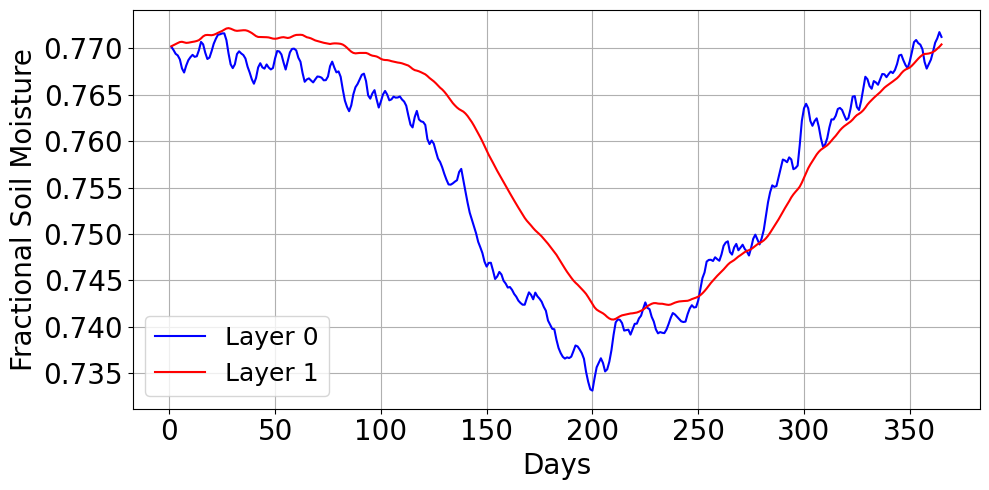

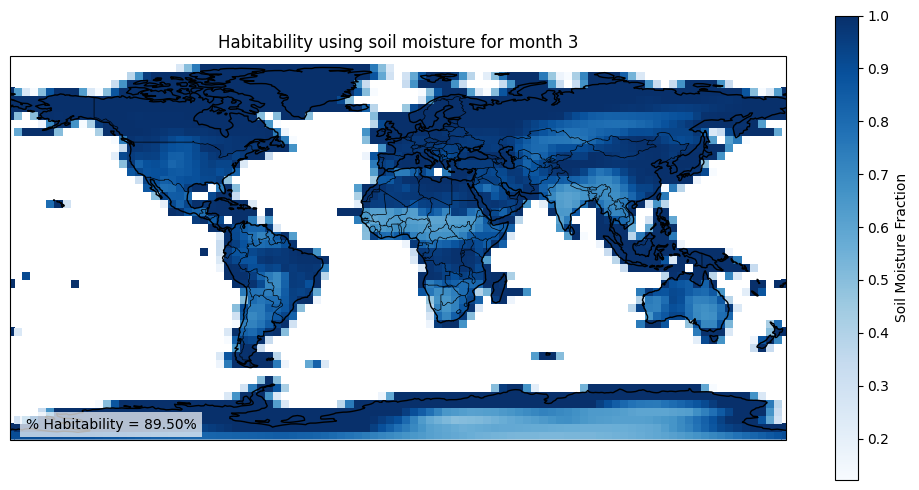

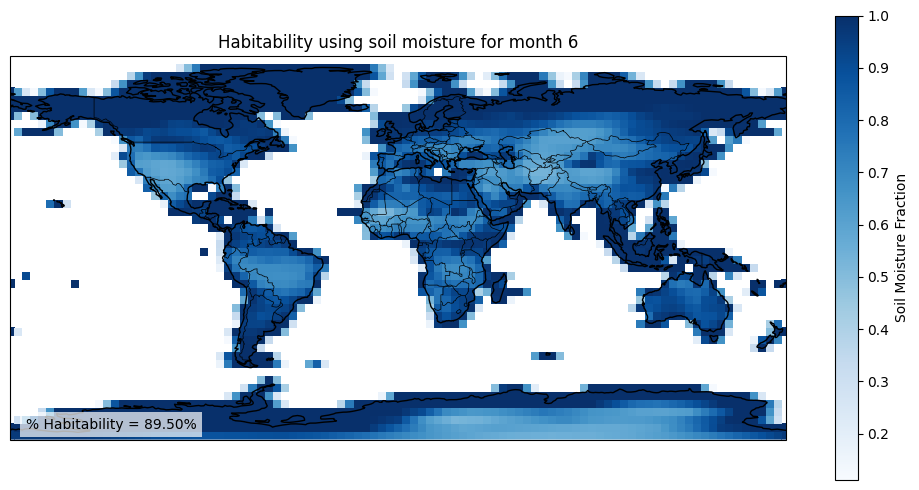

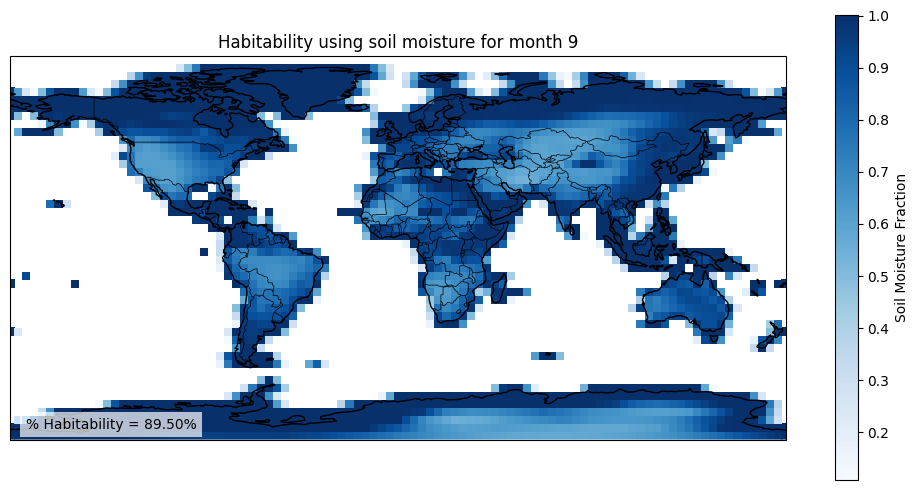

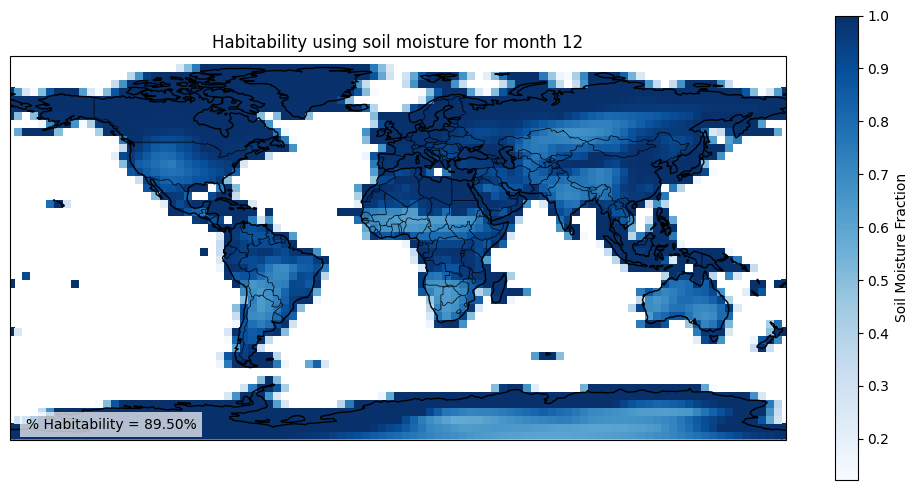

In [265]:
sm_l0 = LandParam.landparam_timeseries(ds_crop["sm"].isel(soil_layer=0),ds_crop["lsm"])
sm_l1 = LandParam.landparam_timeseries(ds_crop["sm"].isel(soil_layer=1),ds_crop["lsm"])

fig = plt.figure(figsize=(10, 5))
plt.plot(times, sm_l0, color='blue', label="Layer 0")
plt.plot(times, sm_l1, color='red', label="Layer 1")
plt.ylabel("Fractional Soil Moisture", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

months_to_keep = [3,6,9,12]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        # Soil Moisture
        fraction = Habitability.fraction(month_ds, "sm")[0]
        mean_plot = Habitability.fraction(month_ds, "sm")[1]
        habitable_plot = Habitability.fraction(month_ds, "sm")[2]

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        mean_plot.where(habitable_plot).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Soil Moisture Fraction"},
            cmap="Blues"
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"% Habitability = {fraction:.2f}%",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Habitability using soil moisture for month {month}")
    
        plt.tight_layout()

## Ice and SSTs

In high solar flux regimes, climate transitions are dominated by water and radiation limits, not ice dynamics

- Weakening ice-albedo feedback (ice disappears - surface mostly land and ocean - ice-albedo feedback negligible)


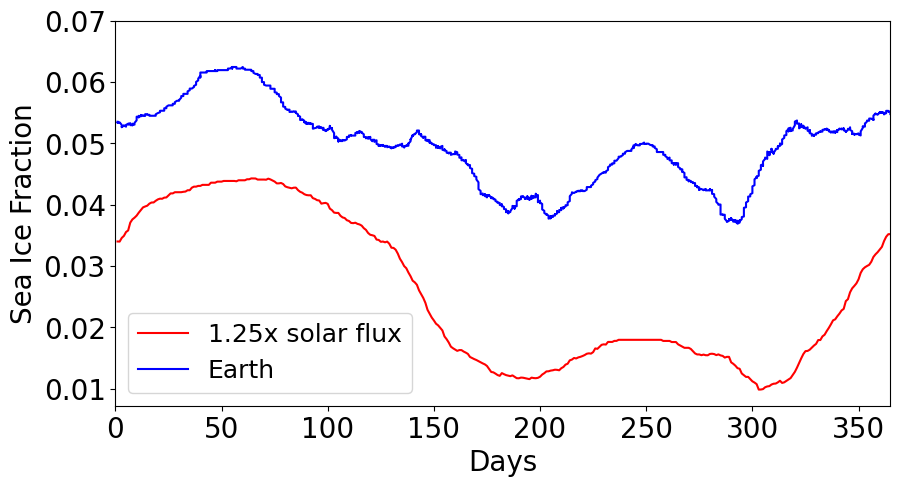

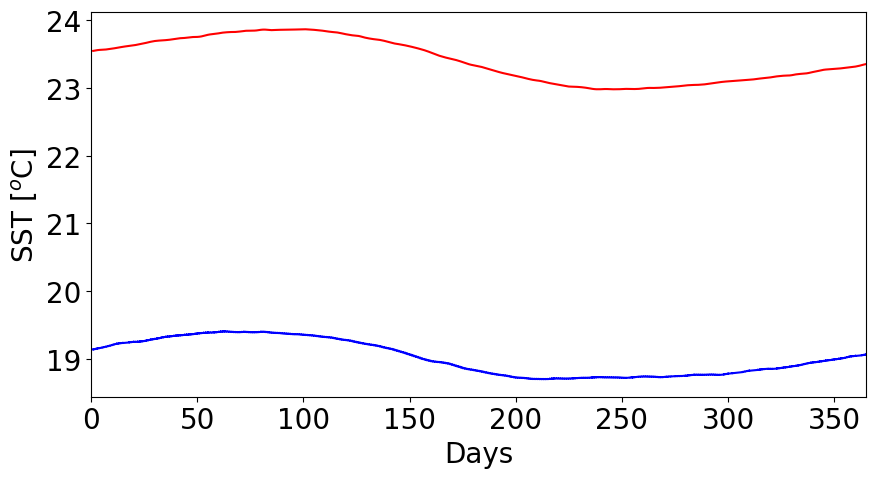

In [283]:
from timeseries_calc import OceanParam, WholeGlobeParam, LandParam, SeaIce

ice_concentration = SeaIce.sic_timeseries(ds_crop["sic"], ds_crop["lsm"])
times = ds_crop.time.dt.dayofyear.values

earth_ice = SeaIce.sic_timeseries(earth_crop["sic"], earth_crop["lsm"])
earth_times = earth_crop.time.dt.dayofyear.values

fig = plt.figure(figsize=(10, 5))
plt.plot(times, ice_concentration, label = "1.25x solar flux", color="red")
plt.plot(earth_times, earth_ice, label = "Earth", color="blue")
plt.xlabel("Days", size=20)
plt.ylabel("Sea Ice Fraction", size=20)
plt.xticks(size=20)
# plt.ylim(0.99,1.01)
plt.xlim(0,365)
plt.yticks([0.01, 0.02, 0.03, 0.04, 0.05,0.06,0.07],size=20)
plt.legend(fontsize=18)
plt.show()

sst = OceanParam.oceanparam_timeseries(ds_crop["sst"], ds_crop["lsm"])
sst_earth = OceanParam.oceanparam_timeseries(earth_crop["sst"], earth_crop["lsm"])
fig = plt.figure(figsize=(10, 5))
plt.plot(times, sst, label = "1.25x solar flux", color="red")
plt.plot(earth_times, sst_earth, label = "Earth", color="blue")
plt.xlabel("Days", size=20)
plt.ylabel("SST [$^o$C]", size=20)
plt.xticks(size=20)
# plt.ylim(0.99,1.01)
plt.xlim(0,365)
plt.yticks(size=20)
plt.show()

## Now Look at humidity, rain, and radiation

In high solar flux regimes, climate transitions are dominated by water and radiation limits, not ice dynamics

Possible scenarios:
- Expansion of tropical zones
- Intensified hydrological cycle
- Weakening ice-albedo feedback (ice disappears - surface mostly land and ocean - ice-albedo feedback negligible)
- Cloud feedback critical (reflect sunlight or trap IR radiation)
- Increased atmospheric moisture leading to large-scale cloud systems
- Moist greenhouse state

Make a global plot every 3 months to see what sea ice, sst, precipitation, temperature is doing
Also make timeseries for each parameter in each hemisphere to see what changes

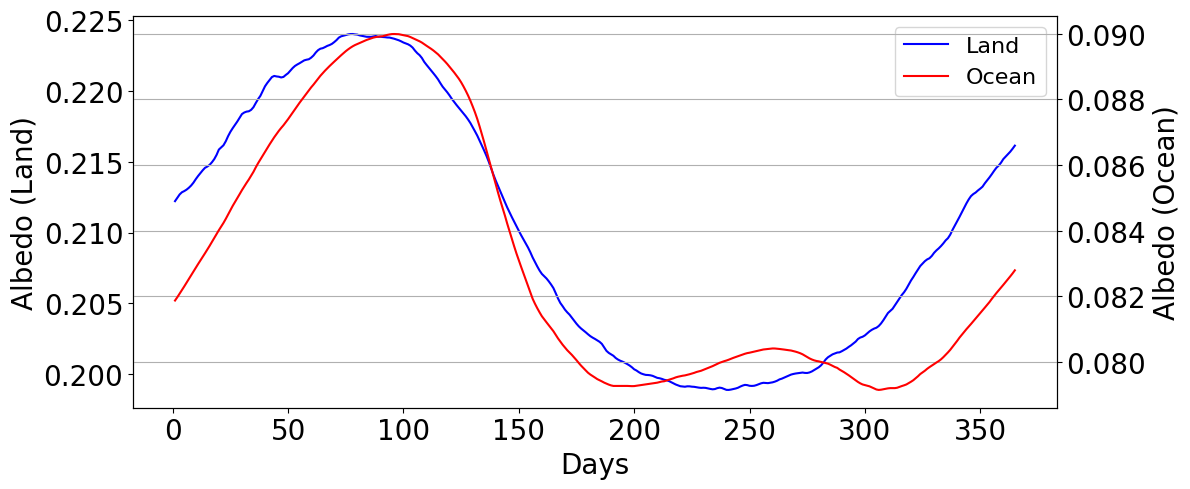

In [ ]:
albedo_land = LandParam.landparam_timeseries(ds_crop["albedo"], ds_crop["lsm"])
albedo_ocean = OceanParam.oceanparam_timeseries(ds_crop["albedo"], ds_crop["lsm"])
times = ds_crop.time.dt.dayofyear.values



fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(times, albedo_land, color='blue', label="Land")
ax1.set_xlabel("Days", size=20)
ax1.set_ylabel("Albedo (Land)", size=20)
# ax1.set_yticks([18.5, 19, 19.5, 20, 20.5])
ax1.tick_params(axis='x', labelsize=20)
ax1.tick_params(axis='y', labelsize=20)

ax2 = ax1.twinx()
ax2.plot(times, albedo_ocean, color='red', label="Ocean")
# ax2.set_yticks([12.4, 12.5, 12.6, 12.7, 12.8, 12.9])
ax2.set_ylabel("Albedo (Ocean)", size=20)
ax2.tick_params(axis='y', labelsize=20)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=16)

plt.grid(True)
plt.tight_layout()
plt.show()



Have seen surface air and soil temperature is very low:

- Seasonality still observed in soil temperature
- Soil moisture much lower

Now check:
- Precipitation (low precipitation could be why soil moisture is low, could be why snow depth is decreasing)
- Cloud cover (could be why albedo/snow is slowly decreasing)
- Radiation budget (small imbalance can melt snow)


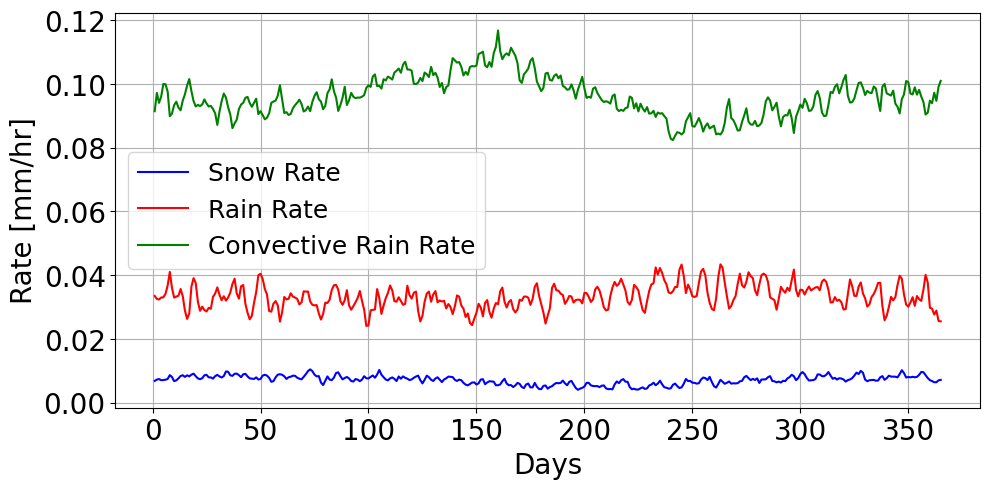

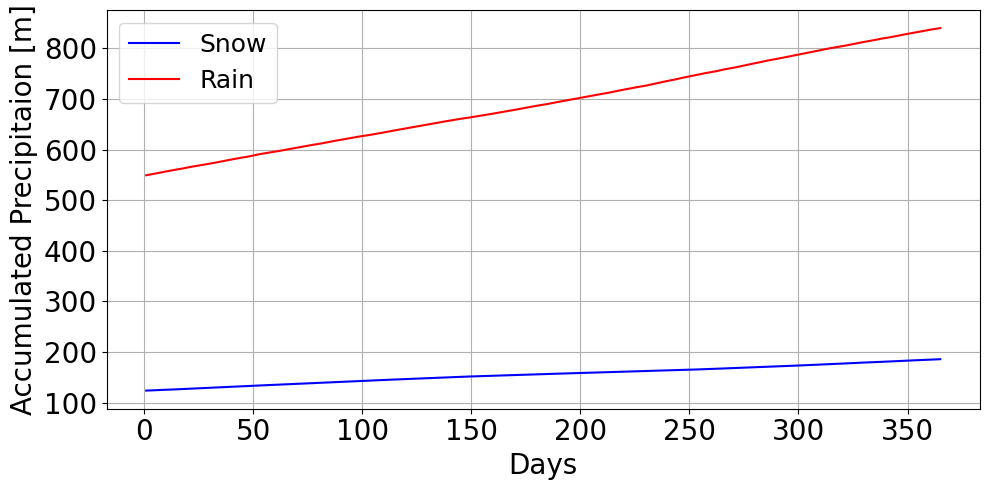

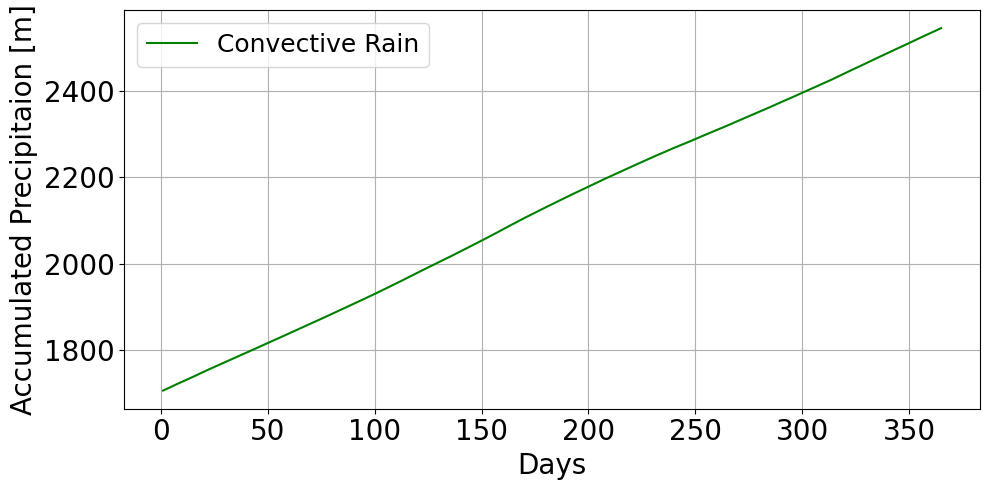

In [273]:
# Snow melt (smelt), snow depth (sd), accumulated snow (snow_cond), snow rate (snow_cond_rate)
# convective rain rate (rain_conv_rate), large-scale rain rate (rain_cond_rate), accumulated covective rain (rain_conv), accumulated large-scale rain (rain_cond)

snow_rate = WholeGlobeParam.globalparam_timeseries(ds_crop["snow_cond_rate"])
rain_rate = WholeGlobeParam.globalparam_timeseries(ds_crop["rain_cond_rate"])
convective_rain_rate = WholeGlobeParam.globalparam_timeseries(ds_crop["rain_conv_rate"])

fig = plt.figure(figsize=(10, 5))
plt.plot(times, snow_rate, color='blue', label="Snow Rate")
plt.plot(times, rain_rate, color='red', label="Rain Rate")
plt.plot(times, convective_rain_rate, color='green', label="Convective Rain Rate")
plt.ylabel("Rate [mm/hr]", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

snow = WholeGlobeParam.globalparam_timeseries(ds_crop["snow_cond"])
rain = WholeGlobeParam.globalparam_timeseries(ds_crop["rain_cond"])
convective_rain = WholeGlobeParam.globalparam_timeseries(ds_crop["rain_conv"])

fig = plt.figure(figsize=(10, 5))
plt.plot(times, snow, color='blue', label="Snow")
plt.plot(times, rain, color='red', label="Rain")
plt.ylabel("Accumulated Precipitaion [m]", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(times, convective_rain, color='green', label="Convective Rain")
plt.ylabel("Accumulated Precipitaion [m]", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()


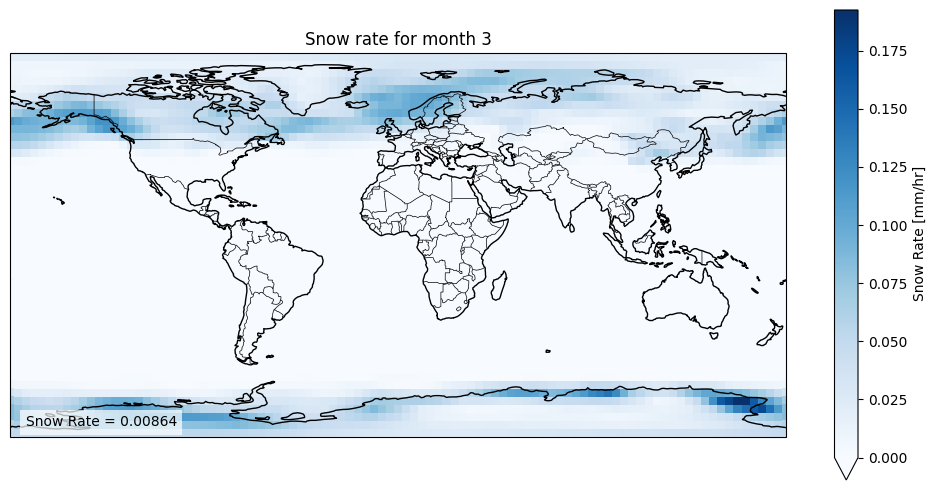

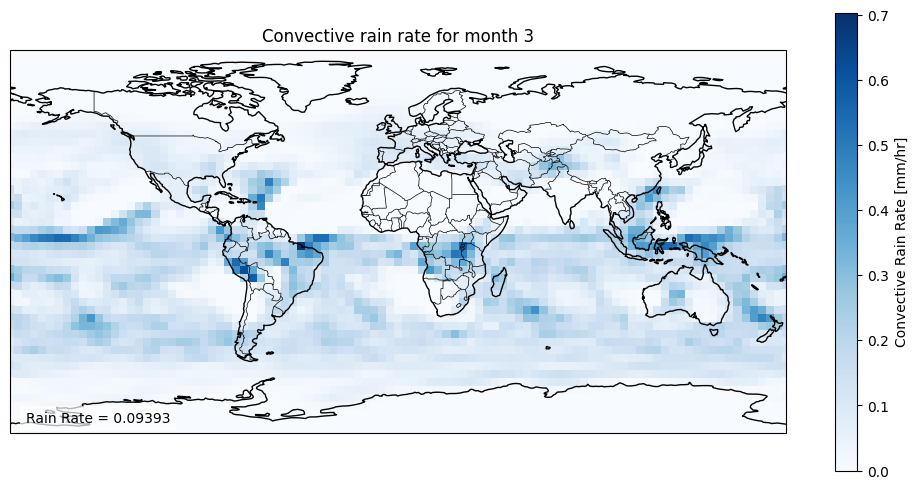

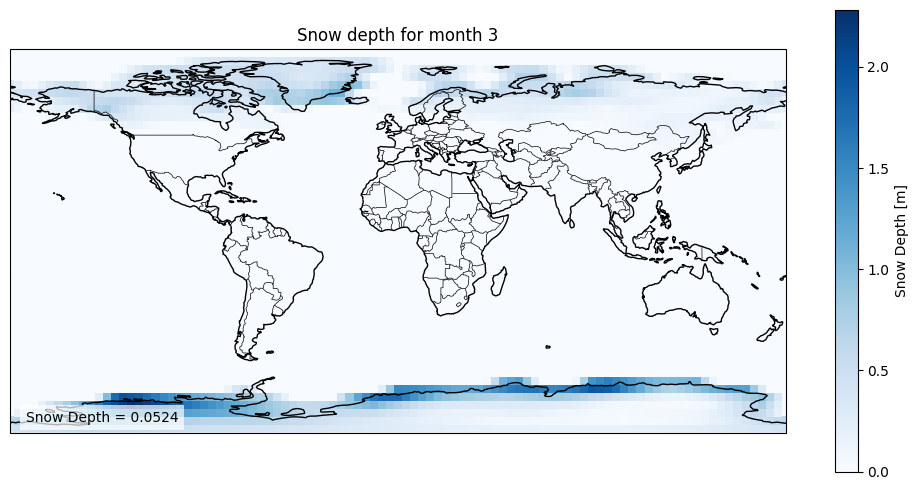

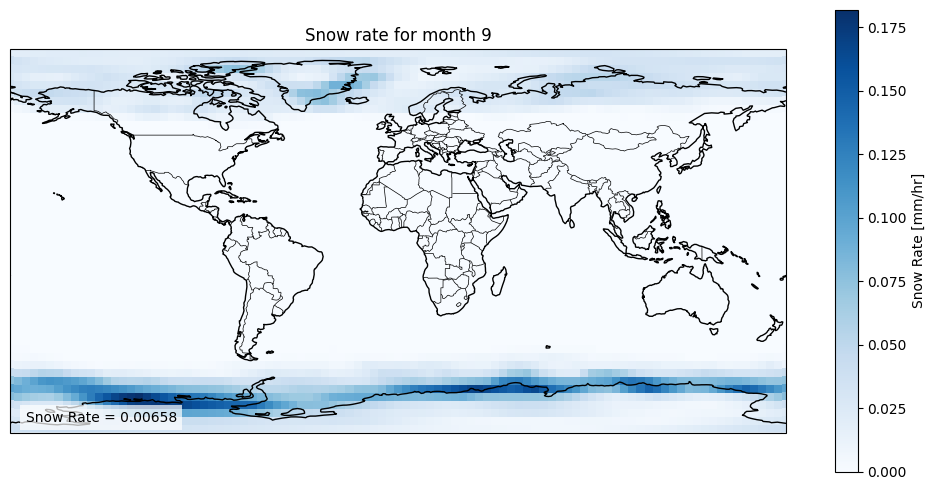

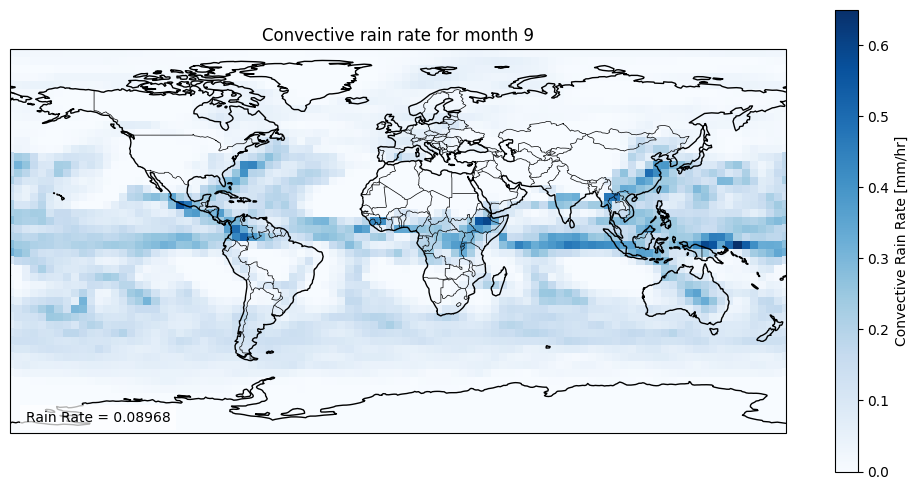

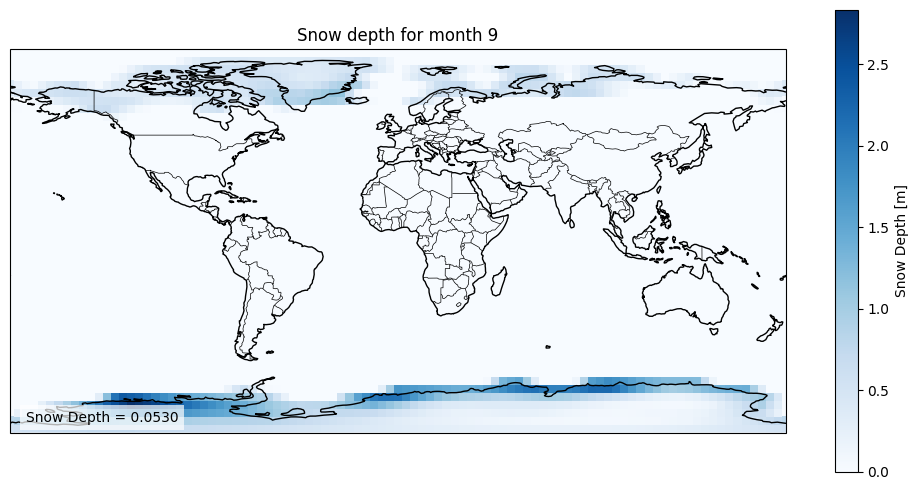

In [274]:
# Check where its snowing vs convectively raining

months_to_keep = [3,9]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        snow_rate = month_ds["snow_cond_rate"]
        snow_mean = snow_rate.mean("time")
  
        # Weights
        lat = snow_mean.lat
        weights = np.cos(np.deg2rad(lat))
        weights = weights.where(np.isfinite(weights), 0)
        weights_2d, _ = xr.broadcast(weights, snow_mean)

        # Area weighted fraction
        numerator_snow = (snow_mean * weights_2d).sum(dim=["lat", "lon"])
        denominator_snow = (weights_2d).sum(dim=["lat", "lon"])
        frac_snow = ( numerator_snow / denominator_snow )

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        snow_mean.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Snow Rate [mm/hr]"},
            cmap="Blues",
            vmin=0
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Snow Rate = {frac_snow:.5f}",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Snow rate for month {month}")
        plt.tight_layout() 

        convrain_rate = month_ds["rain_conv_rate"]
        rain_mean = convrain_rate.mean("time")

        # Area weighted fraction
        numerator_rain = (rain_mean * weights_2d).sum(dim=["lat", "lon"])
        denominator_rain = (weights_2d).sum(dim=["lat", "lon"])
        frac_rain = ( numerator_rain / denominator_rain )

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        rain_mean.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Convective Rain Rate [mm/hr]"},
            cmap="Blues",
            vmin=0
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Rain Rate = {frac_rain:.5f}",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Convective rain rate for month {month}")
        plt.tight_layout() 

        sd = month_ds["sd"]
        sd_mean = sd.mean("time")

        # Area weighted fraction
        numerator_sd = (sd_mean * weights_2d).sum(dim=["lat", "lon"])
        denominator_sd = (weights_2d).sum(dim=["lat", "lon"])
        frac_sd = ( numerator_sd / denominator_sd )

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        sd_mean.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Snow Depth [m]"},
            cmap="Blues",
            vmin=0
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Snow Depth = {frac_sd:.4f}",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Snow depth for month {month}")
        plt.tight_layout() 

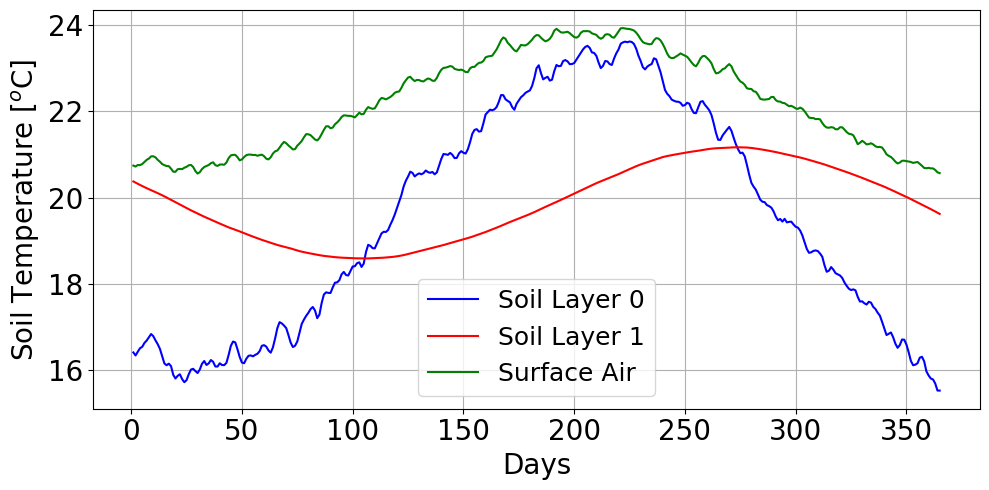

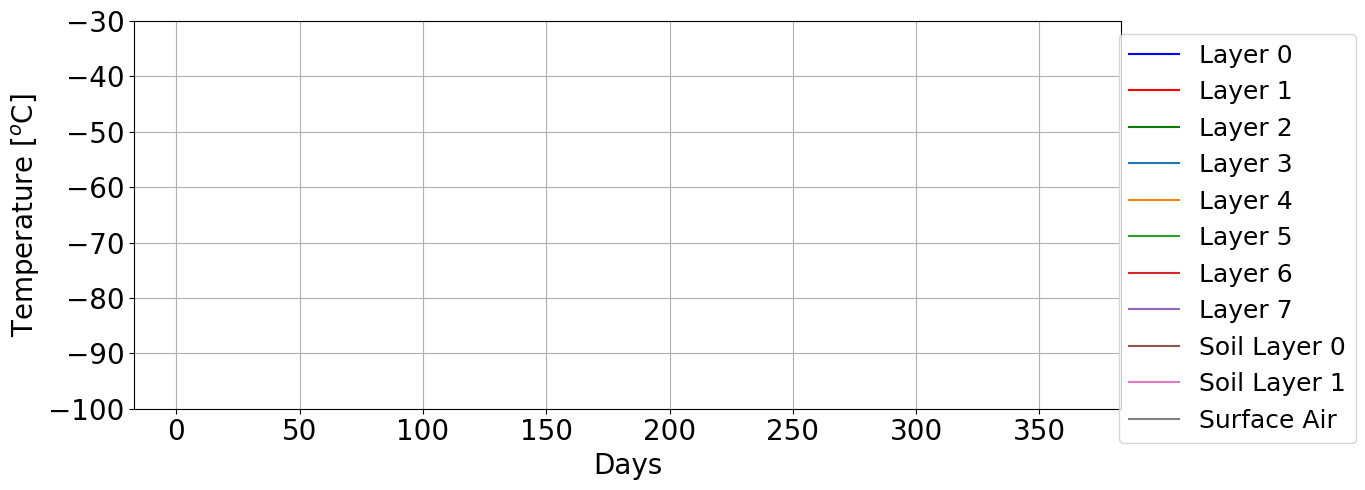

In [275]:
# Look at temperature in general (not habitability)

st_l0 = LandParam.landparam_timeseries(ds_crop["st"].isel(soil_layer=0),ds_crop["lsm"])
st_l1 = LandParam.landparam_timeseries(ds_crop["st"].isel(soil_layer=1),ds_crop["lsm"])
ts = WholeGlobeParam.globalparam_timeseries(ds_crop["tsurf"])

fig = plt.figure(figsize=(10, 5))
plt.plot(times, st_l0, color='blue', label="Soil Layer 0")
plt.plot(times, st_l1, color='red', label="Soil Layer 1")
plt.plot(times, ts, color='green', label="Surface Air")
plt.ylabel("Soil Temperature [$^o$C]", size=20)
plt.xlabel('Days', size=20)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18)
plt.tight_layout()
plt.show()

t0 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=0))
t1 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=1))
t2 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=2))
t3 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=3))
t4 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=4))
t5 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=5))
t6 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=6))
t7 = WholeGlobeParam.globalparam_timeseries(ds_crop["temp"].isel(layer=7))

fig = plt.figure(figsize=(14, 5))
plt.plot(times, t0, color='blue', label="Layer 0")
plt.plot(times, t1, color='red', label="Layer 1")
plt.plot(times, t2, color='green', label="Layer 2")
plt.plot(times, t3, label="Layer 3")
plt.plot(times, t4, label="Layer 4")
plt.plot(times, t5, label="Layer 5")
plt.plot(times, t6, label="Layer 6")
plt.plot(times, t7, label="Layer 7")
plt.plot(times, st_l0, label="Soil Layer 0")
plt.plot(times, st_l1, label="Soil Layer 1")
plt.plot(times, ts, label="Surface Air")
plt.ylabel("Temperature [$^o$C]", size=20)
plt.xlabel('Days', size=20)
plt.ylim(-100,-30)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18,  loc="upper right", bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()

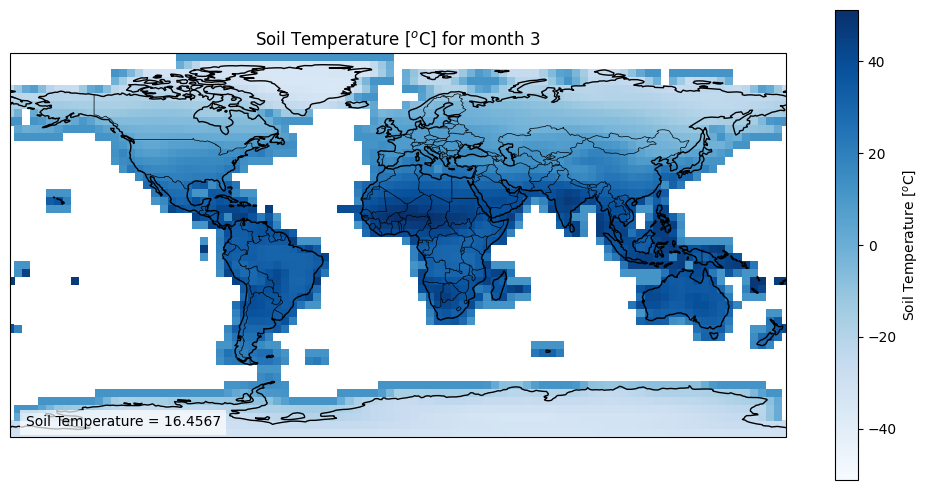

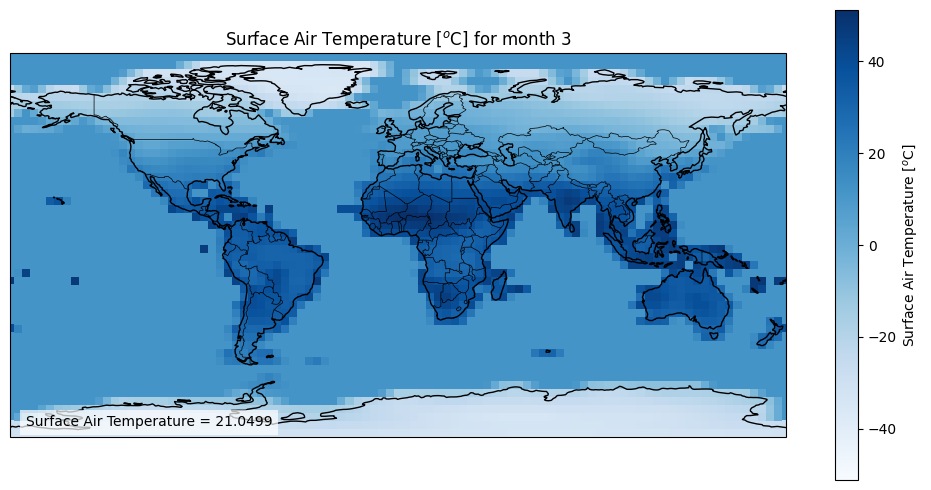

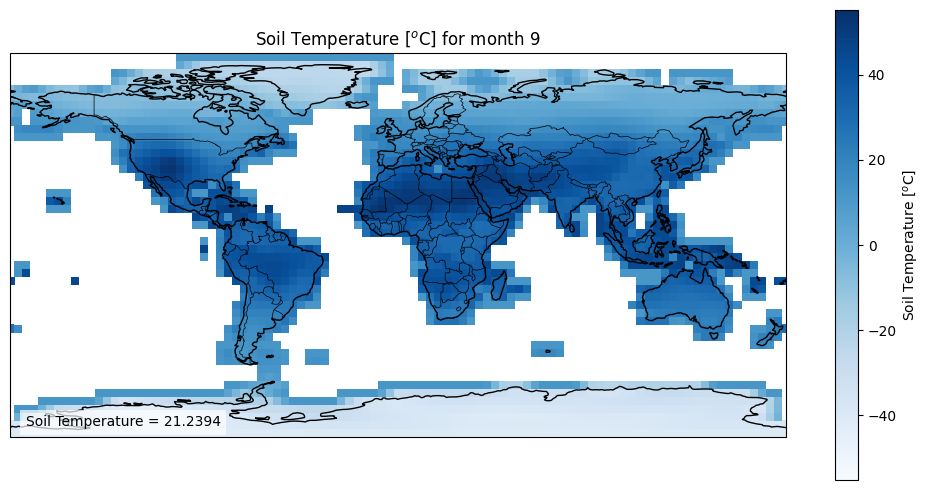

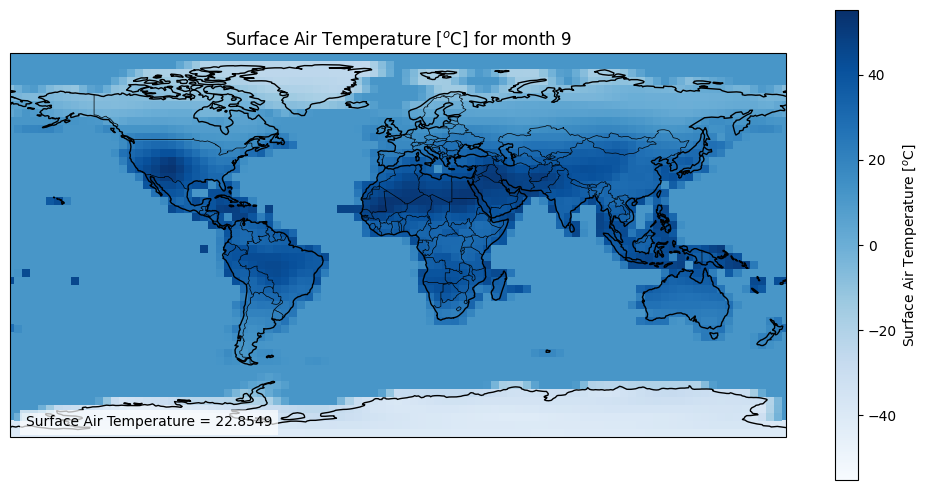

In [276]:
# Check where its snowing vs convectively raining

months_to_keep = [3,9]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        st = month_ds["st"].isel(soil_layer=0)

        land = month_ds["lsm"].any("time")

        st_mean = st.mean("time")
        tsurf = month_ds["tsurf"]
        ts_mean = tsurf.mean("time")

        # Weights
        lat = land["lat"]
        weights = np.cos(np.deg2rad(lat))
        weights = weights.where(np.isfinite(weights), 0)
        weights_2d, _ = xr.broadcast(weights, land)

        # Area weighted fraction
        numerator_st = (st_mean * land * weights_2d).sum(dim=["lat", "lon"])
        denominator_st = (land * weights_2d).sum(dim=["lat", "lon"])
        frac_st = ( numerator_st / denominator_st )

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        st_mean.where(land).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Soil Temperature [$^o$C]"},
            cmap="Blues",
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Soil Temperature = {frac_st:.4f}",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Soil Temperature [$^o$C] for month {month}")
        plt.tight_layout() 

        # Weights
        lat = ts_mean.lat
        weights = np.cos(np.deg2rad(lat))
        weights = weights.where(np.isfinite(weights), 0)
        weights_2d, _ = xr.broadcast(weights, ts_mean)

        # Area weighted fraction
        numerator_ts = (ts_mean * weights_2d).sum(dim=["lat", "lon"])
        denominator_ts = (weights_2d).sum(dim=["lat", "lon"])
        frac_ts = ( numerator_ts / denominator_ts )

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        st_mean.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Surface Air Temperature [$^o$C]"},
            cmap="Blues",
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Surface Air Temperature = {frac_ts:.4f}",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Surface Air Temperature [$^o$C] for month {month}")
        plt.tight_layout() 

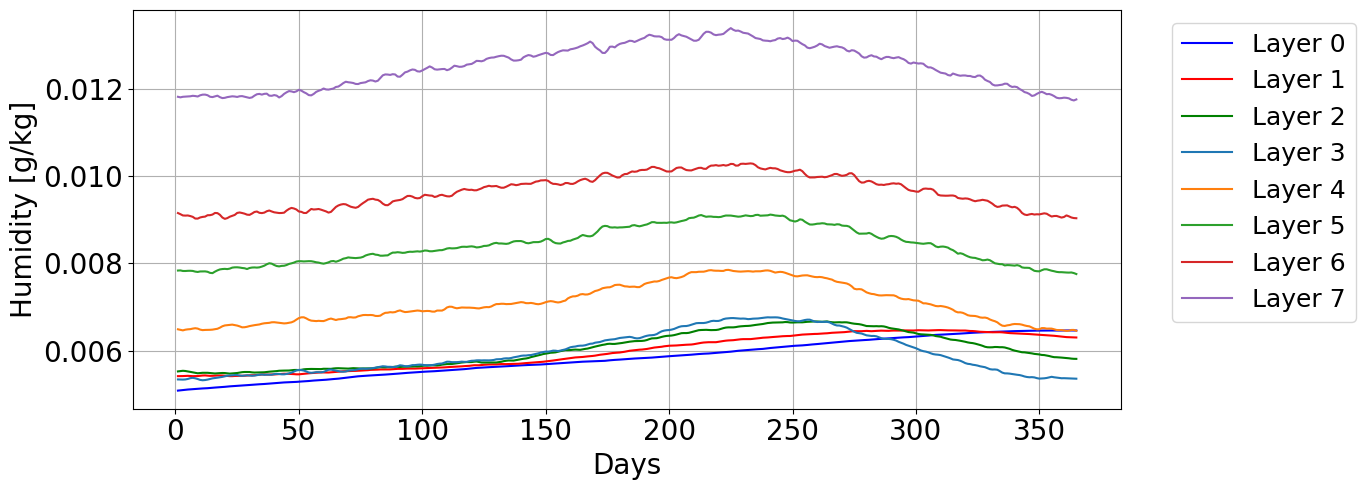

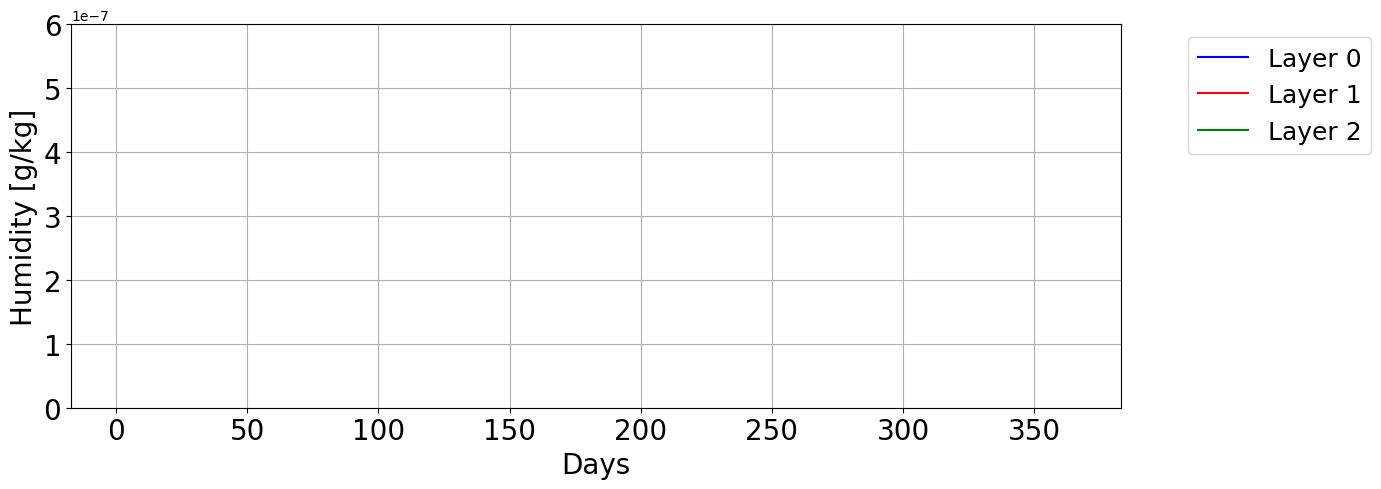

In [277]:
h0 = WholeGlobeParam.globalparam_timeseries(ds_crop["humid"].isel(layer=0))
h1 = WholeGlobeParam.globalparam_timeseries(ds_crop["humid"].isel(layer=1))
h2 = WholeGlobeParam.globalparam_timeseries(ds_crop["humid"].isel(layer=2))
h3 = WholeGlobeParam.globalparam_timeseries(ds_crop["humid"].isel(layer=3))
h4 = WholeGlobeParam.globalparam_timeseries(ds_crop["humid"].isel(layer=4))
h5 = WholeGlobeParam.globalparam_timeseries(ds_crop["humid"].isel(layer=5))
h6 = WholeGlobeParam.globalparam_timeseries(ds_crop["humid"].isel(layer=6))
h7 = WholeGlobeParam.globalparam_timeseries(ds_crop["humid"].isel(layer=7))

fig = plt.figure(figsize=(14, 5))
plt.plot(times, h0, color='blue', label="Layer 0")
plt.plot(times, h1, color='red', label="Layer 1")
plt.plot(times, h2, color='green', label="Layer 2")
plt.plot(times, h3, label="Layer 3")
plt.plot(times, h4, label="Layer 4")
plt.plot(times, h5, label="Layer 5")
plt.plot(times, h6, label="Layer 6")
plt.plot(times, h7, label="Layer 7")
plt.ylabel("Humidity [g/kg]", size=20)
plt.xlabel('Days', size=20)
# plt.ylim(-100,-30)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18,  loc="upper right", bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(14, 5))
plt.plot(times, h0, color='blue', label="Layer 0")
plt.plot(times, h1, color='red', label="Layer 1")
plt.plot(times, h2, color='green', label="Layer 2")
plt.ylabel("Humidity [g/kg]", size=20)
plt.xlabel('Days', size=20)
plt.ylim(0e-7,6e-7)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18,  loc="upper right", bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()

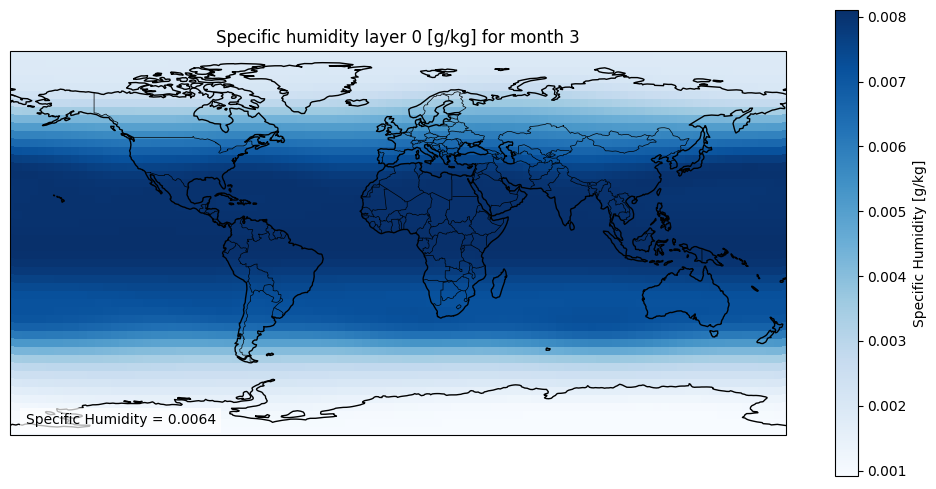

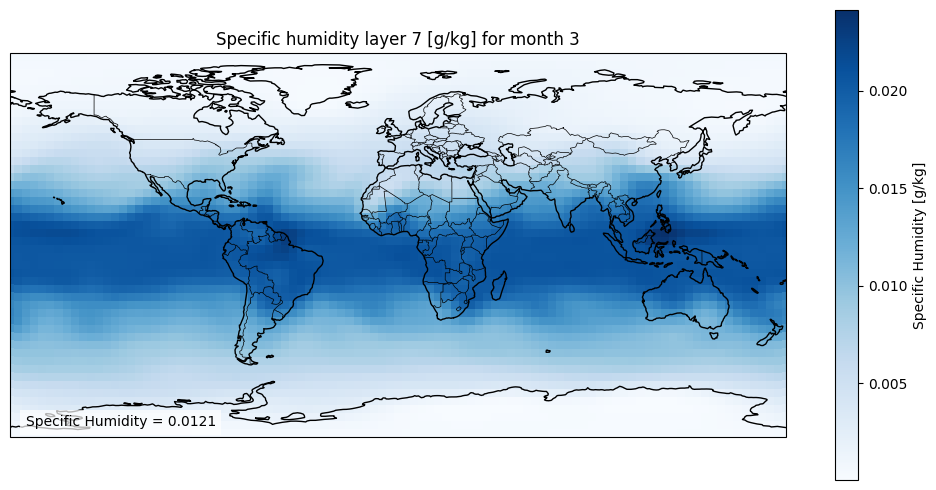

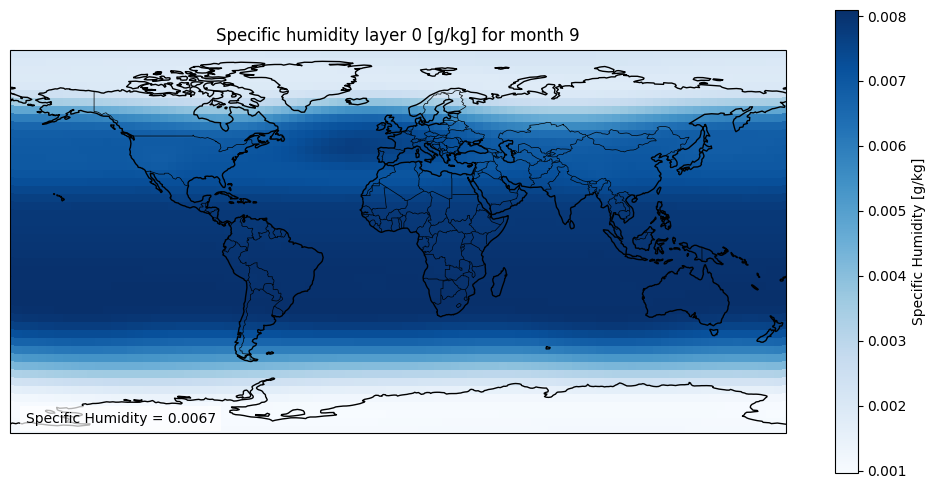

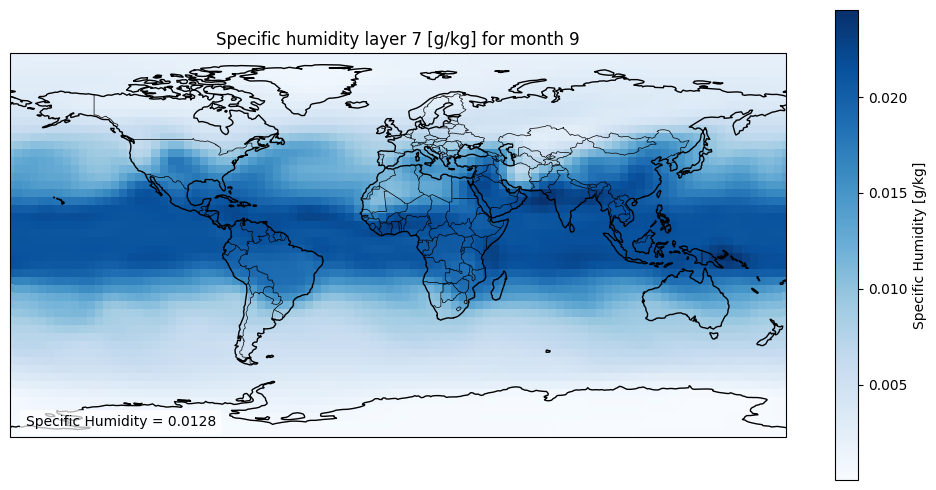

In [278]:
# Check where its snowing vs convectively raining

months_to_keep = [3,9]
for month, month_ds in grouped_data:
    if month in months_to_keep:

        h0 = month_ds["humid"].isel(layer=0)
        h7 = month_ds["humid"].isel(layer=7)

        h0_mean = h0.mean("time")
        h7_mean = h7.mean("time")

        # Weights
        lat = h0_mean["lat"]
        weights = np.cos(np.deg2rad(lat))
        weights = weights.where(np.isfinite(weights), 0)
        weights_2d, _ = xr.broadcast(weights, h0_mean)

        # Area weighted fraction
        numerator_h0 = (h0_mean * weights_2d).sum(dim=["lat", "lon"])
        denominator_h0 = (weights_2d).sum(dim=["lat", "lon"])
        frac_h0 = ( numerator_h0 / denominator_h0 )

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        h0_mean.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Specific Humidity [g/kg]"},
            cmap="Blues",
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Specific Humidity = {frac_h0:.4f}",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Specific humidity layer 0 [g/kg] for month {month}")
        plt.tight_layout() 

        # Area weighted fraction
        numerator_h7 = (h7_mean * weights_2d).sum(dim=["lat", "lon"])
        denominator_h7 = (weights_2d).sum(dim=["lat", "lon"])
        frac_h7 = ( numerator_h7 / denominator_h7 )

        # Creating figures
        fig = plt.figure(figsize=(10, 5))
        ax = plt.axes(projection=ccrs.PlateCarree())

        h7_mean.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={"label": "Specific Humidity [g/kg]"},
            cmap="Blues",
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(0.02, 0.02, f"Specific Humidity = {frac_h7:.4f}",
            transform=ax.transAxes,
            ha="left", va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

        plt.title(f"Specific humidity layer 7 [g/kg] for month {month}")
        plt.tight_layout() 

In [279]:
print(ds_crop.variables)

Frozen({'rain_conv': <xarray.Variable (time: 365, lat: 48, lon: 96)> Size: 7MB
[1681920 values with dtype=float32]
Attributes:
    units:      mm
    long_name:  accumulated convective rain, 'sru': <xarray.Variable (time: 365, lat: 48, lon: 96)> Size: 7MB
[1681920 values with dtype=float32]
Attributes:
    units:      W/m^2
    long_name:  Surface shortwave radiation up, 'rain_cond': <xarray.Variable (time: 365, lat: 48, lon: 96)> Size: 7MB
[1681920 values with dtype=float32]
Attributes:
    units:      mm
    long_name:  accumulated large-scale rain, 'lsm': <xarray.Variable (time: 365, lat: 48, lon: 96)> Size: 7MB
array([[[0.000000e+00, 0.000000e+00, ..., 1.641638e-09, 8.208190e-10],
        [0.000000e+00, 0.000000e+00, ..., 5.001068e-03, 2.500534e-03],
        ...,
        [1.000000e+00, 1.000000e+00, ..., 1.000000e+00, 1.000000e+00],
        [1.000000e+00, 1.000000e+00, ..., 1.000000e+00, 1.000000e+00]],

       [[0.000000e+00, 0.000000e+00, ..., 1.641638e-09, 8.208190e-10],
       

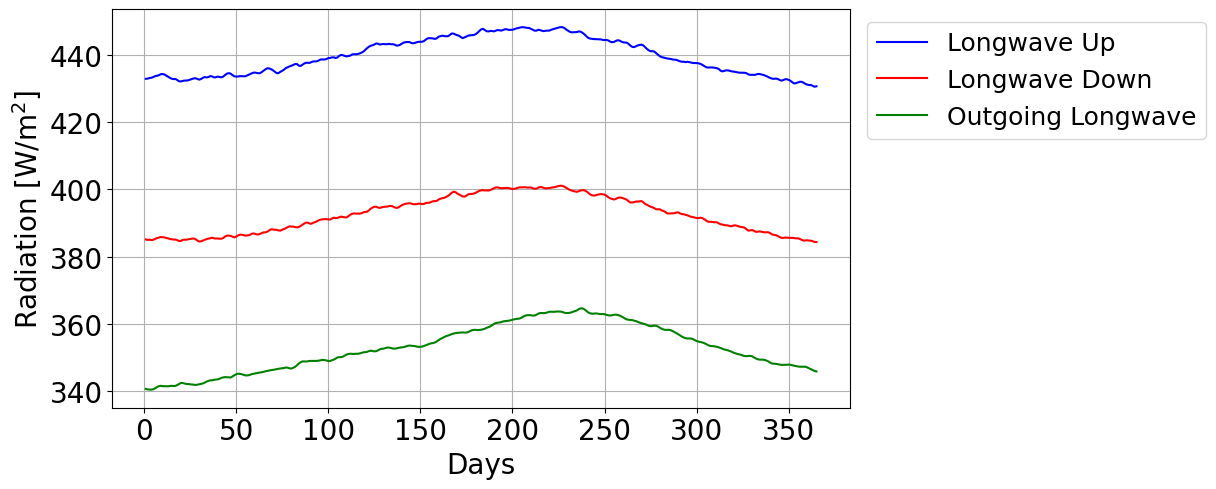

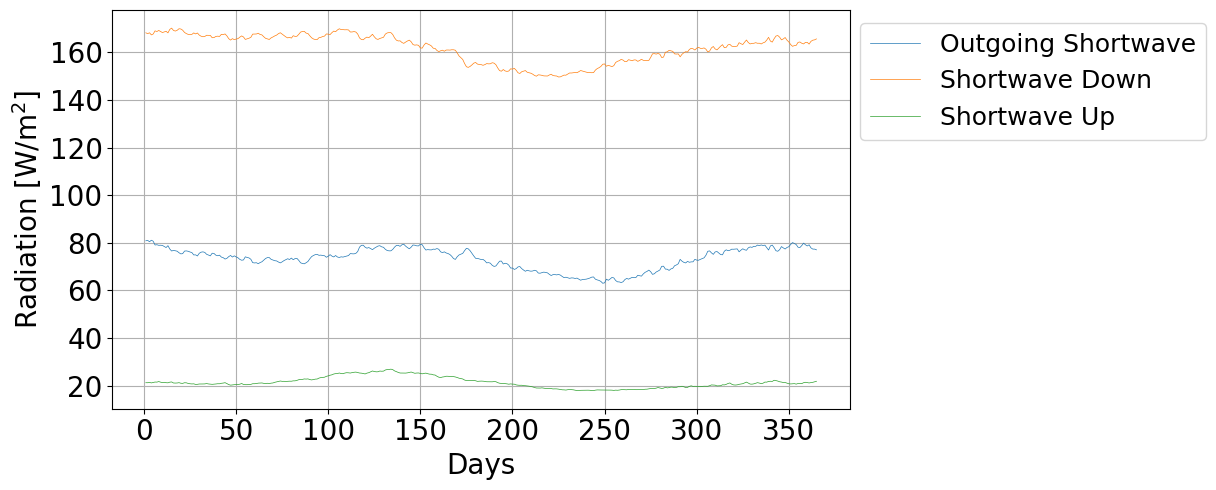

In [280]:
# Radiation budget
    # Surface longwave radiation up lru
    # Outgoing longwave radiation olr
    # Surface longwave radiation down lrd
    # Outgoing shortwave radiation osr
    # Surface shortwave radiation down srd
    # Surface shortwave radiation up sru

lru = WholeGlobeParam.globalparam_timeseries(ds_crop["lru"])
lrd = WholeGlobeParam.globalparam_timeseries(ds_crop["lrd"])
olr = WholeGlobeParam.globalparam_timeseries(ds_crop["olr"])
osr = WholeGlobeParam.globalparam_timeseries(ds_crop["osr"])
srd = WholeGlobeParam.globalparam_timeseries(ds_crop["srd"])
sru = WholeGlobeParam.globalparam_timeseries(ds_crop["sru"])

fig = plt.figure(figsize=(14, 5))
plt.plot(times, lru, color='blue', label="Longwave Up")
plt.plot(times, lrd, color='red', label="Longwave Down")
plt.plot(times, olr, color='green', label="Outgoing Longwave")
plt.ylabel("Radiation [W/m$^2$]", size=20)
plt.xlabel('Days', size=20)
# plt.ylim(-100,-30)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18,  loc="upper right", bbox_to_anchor=(1.5, 1))
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(14, 5))
plt.plot(times, osr, label="Outgoing Shortwave",linewidth=0.5)
plt.plot(times, srd, label="Shortwave Down", linewidth=0.5)
plt.plot(times, sru, label="Shortwave Up", linewidth=0.5)
plt.ylabel("Radiation [W/m$^2$]", size=20)
plt.xlabel('Days', size=20)
# plt.ylim(-100,-30)
plt.xticks(size=20)
plt.yticks(size=20)
plt.grid(True)
plt.legend(fontsize=18,  loc="upper right", bbox_to_anchor=(1.5, 1))
plt.tight_layout()
plt.show()